# Stock Price Prediction using LSTM and RNN

---

## Table of Contents
1. [Project Overview & Problem Statement](#1-project-overview)
2. [Setup & Import Libraries](#2-setup)
3. [Data Collection](#3-data-collection)
4. [Data Understanding & Feature Types](#4-data-understanding)
5. [Data Quality Assessment](#5-data-quality)
6. [Exploratory Data Analysis (EDA)](#6-eda)
7. [Hypothesis Formulation & Statistical Testing](#7-hypothesis)
8. [Feature Engineering](#8-feature-engineering)
9. [Data Preprocessing for Deep Learning](#9-preprocessing)
10. [Model Architecture & Theory](#10-model-theory)
11. [Model Development & Training](#11-model-development)
12. [Model Evaluation & Comparison](#12-evaluation)
13. [Prediction Analysis & Visualization](#13-prediction-analysis)
14. [Future Forecasting](#14-future-forecasting)
15. [Limitations & Challenges](#15-limitations)
16. [Conclusions & Recommendations](#16-conclusions)

---

## 1. Project Overview & Problem Statement <a name="1-project-overview"></a>

### 1.1 Business Context
Stock price prediction is a critical challenge in the financial industry. Accurate forecasting can help investors make informed decisions, optimize portfolio allocation, and manage risk effectively.

### 1.2 Problem Statement
**Objective**: Develop deep learning models (RNN and LSTM) to predict future stock closing prices based on historical price data and technical indicators.

**Key Questions:**
1. Can we predict tomorrow's closing price using historical data?
2. Do technical indicators (RSI, EMA, MACD) improve prediction accuracy?
3. Which model architecture performs best for stock prediction?
4. What are the practical limitations of ML-based stock prediction?

### 1.3 Success Metrics
- **RMSE (Root Mean Squared Error)**: Primary metric - lower is better
- **MAE (Mean Absolute Error)**: Average prediction error in dollars
- **MAPE (Mean Absolute Percentage Error)**: Percentage-based error
- **R² Score**: Variance explained by the model
- **Direction Accuracy**: Correct up/down prediction percentage

### 1.4 Project Scope
- **Stock**: Apple Inc. (AAPL) - Selected for high liquidity and data availability
- **Data Source**: NASDAQ Stock Market Dataset (Kaggle)
- **Time Period**: Full historical data available
- **Prediction Horizon**: Next-day closing price prediction

---

## 2. Setup & Import Libraries <a name="2-setup"></a>

### Required Libraries:
- **Data Manipulation**: NumPy, Pandas
- **Visualization**: Matplotlib, Seaborn
- **Deep Learning**: TensorFlow/Keras
- **Statistical Analysis**: SciPy
- **Preprocessing**: Scikit-learn

In [1]:
# Core Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
from datetime import datetime

warnings.filterwarnings('ignore')

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, SimpleRNN, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Preprocessing & Metrics
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Statistical Analysis
from scipy import stats
from scipy.stats import shapiro, normaltest, jarque_bera

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# Visualization Configuration
COLORS = {
    'primary': '#1E3A5F',
    'secondary': '#3D7EA6',
    'accent': '#F39C12',
    'success': '#27AE60',
    'danger': '#E74C3C',
    'warning': '#F1C40F',
    'info': '#3498DB',
    'light': '#ECF0F1',
    'dark': '#2C3E50',
    'purple': '#9B59B6',
    'teal': '#1ABC9C',
}

PALETTE_SEQUENTIAL = ['#1E3A5F', '#2E5077', '#3D7EA6', '#5DADE2', '#85C1E9', '#AED6F1']
PALETTE_DIVERGING = ['#E74C3C', '#F1948A', '#FADBD8', '#D5F5E3', '#82E0AA', '#27AE60']
PALETTE_CATEGORICAL = ['#1E3A5F', '#27AE60', '#F39C12', '#E74C3C', '#9B59B6', '#1ABC9C']

plt.rcParams.update({
    'figure.figsize': (14, 8),
    'figure.dpi': 100,
    'figure.facecolor': 'white',
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'axes.facecolor': 'white',
    'axes.grid': True,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.prop_cycle': plt.cycler(color=PALETTE_CATEGORICAL),
    'grid.color': '#E5E5E5',
    'grid.alpha': 0.7,
    'legend.fontsize': 10,
    'legend.frameon': True,
    'legend.framealpha': 0.9,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'lines.linewidth': 2,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.1)

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)


def add_value_labels(ax, spacing=5, fmt='{:.1f}', fontsize=9):
    """Add value labels to bar charts."""
    for rect in ax.patches:
        y_value = rect.get_height()
        x_value = rect.get_x() + rect.get_width() / 2
        va = 'bottom' if y_value >= 0 else 'top'
        ax.annotate(
            fmt.format(y_value), (x_value, y_value),
            xytext=(0, spacing if y_value >= 0 else -spacing),
            textcoords="offset points", ha='center', va=va,
            fontsize=fontsize, color=COLORS['dark']
        )


def format_axis(ax, title, xlabel=None, ylabel=None):
    """Apply consistent formatting to axis."""
    ax.set_title(title, fontsize=14, fontweight='bold', color=COLORS['dark'], pad=15)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=11, color=COLORS['dark'])
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=11, color=COLORS['dark'])


print(f"TensorFlow: {tf.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")

TensorFlow: 2.20.0
NumPy: 2.3.5
Pandas: 2.3.1


## 3. Data Collection <a name="3-data-collection"></a>

### 3.1 Data Source
- **Dataset**: NASDAQ Stock Market Dataset
- **Source**: Kaggle (jacksoncrow/stock-market-dataset)
- **Format**: CSV files organized by stock symbol
- **Coverage**: Historical daily prices for all NASDAQ-traded stocks

In [2]:
# Download dataset from Kaggle
import kagglehub

# Download the NASDAQ stock market dataset
path = kagglehub.dataset_download("jacksoncrow/stock-market-dataset")
print(f"Dataset downloaded to: {path}")

# Dataset Structure
print("\nDATASET STRUCTURE")
print("=" * 60)

for item in os.listdir(path):
    item_path = os.path.join(path, item)
    if os.path.isdir(item_path):
        file_count = len(os.listdir(item_path))
        print(f"{item}/ - {file_count:,} files")
    else:
        file_size = os.path.getsize(item_path) / 1024
        print(f"{item} - {file_size:.2f} KB")

Dataset downloaded to: /Users/nusratbegum/.cache/kagglehub/datasets/jacksoncrow/stock-market-dataset/versions/2

DATASET STRUCTURE
symbols_valid_meta.csv - 597.29 KB
stocks/ - 5,884 files
etfs/ - 2,165 files


In [3]:
# Load Metadata
meta_df = pd.read_csv(os.path.join(path, 'symbols_valid_meta.csv'))

print("METADATA OVERVIEW")
print("=" * 60)
print(f"Total Symbols: {len(meta_df):,}")
print(f"Columns: {meta_df.columns.tolist()}")
display(meta_df.head(10))

METADATA OVERVIEW
Total Symbols: 8,049
Columns: ['Nasdaq Traded', 'Symbol', 'Security Name', 'Listing Exchange', 'Market Category', 'ETF', 'Round Lot Size', 'Test Issue', 'Financial Status', 'CQS Symbol', 'NASDAQ Symbol', 'NextShares']


,Nasdaq Traded,Symbol,Security Name,Listing Exchange,Market Category,ETF,Round Lot Size,Test Issue,Financial Status,CQS Symbol,NASDAQ Symbol,NextShares
0,Y,A,"Agilent Technologies, Inc. Common Stock",N,,N,100.0000,N,NaN,A,A,N
1,Y,AA,Alcoa Corporation Common Stock,N,,N,100.0000,N,NaN,AA,AA,N
2,Y,AAAU,Perth Mint Physical Gold ETF,P,,Y,100.0000,N,NaN,AAAU,AAAU,N
3,Y,AACG,ATA Creativity Global - American Depositary Sh...,Q,G,N,100.0000,N,N,NaN,AACG,N
4,Y,AADR,AdvisorShares Dorsey Wright ADR ETF,P,,Y,100.0000,N,NaN,AADR,AADR,N
5,Y,AAL,"American Airlines Group, Inc. - Common Stock",Q,Q,N,100.0000,N,N,NaN,AAL,N
6,Y,AAMC,Altisource Asset Management Corp Com,A,,N,100.0000,N,NaN,AAMC,AAMC,N
7,Y,AAME,Atlantic American Corporation - Common Stock,Q,G,N,100.0000,N,N,NaN,AAME,N
8,Y,AAN,"Aaron's, Inc. Common Stock",N,,N,100.0000,N,NaN,AAN,AAN,N
9,Y,AAOI,"Applied Optoelectronics, Inc. - Common Stock",Q,G,N,100.0000,N,N,NaN,AAOI,N


In [4]:
# Load Target Stock Data (Apple - AAPL)
STOCK_SYMBOL = 'AAPL'
stock_path = os.path.join(path, 'stocks', f'{STOCK_SYMBOL}.csv')

df = pd.read_csv(stock_path)
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df.sort_index(inplace=True)

print(f"{STOCK_SYMBOL} DATA LOADED")
print("=" * 60)
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Date Range: {df.index.min().strftime('%Y-%m-%d')} to {df.index.max().strftime('%Y-%m-%d')}")
print(f"Time Span: {(df.index.max() - df.index.min()).days:,} days")
print(f"Trading Days: {len(df):,}")
display(df.head())

AAPL DATA LOADED
Shape: 9,909 rows x 6 columns
Date Range: 1980-12-12 to 2020-04-01
Time Span: 14,355 days
Trading Days: 9,909


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
1980-12-12,0.5134,0.5156,0.5134,0.5134,0.4068,117258400
1980-12-15,0.4888,0.4888,0.4866,0.4866,0.3856,43971200
1980-12-16,0.4531,0.4531,0.4509,0.4509,0.3573,26432000
1980-12-17,0.4621,0.4643,0.4621,0.4621,0.3661,21610400
1980-12-18,0.4754,0.4777,0.4754,0.4754,0.3767,18362400


## 4. Data Understanding & Feature Types <a name="4-data-understanding"></a>

### 4.1 Data Dictionary
Understanding each feature in our dataset is crucial for proper analysis and modeling.

In [5]:
# ============================================================
# 4.2 DATA DICTIONARY
# ============================================================
data_dictionary = pd.DataFrame({
    'Feature': ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'],
    'Description': [
        'Trading date',
        'Opening price at market open',
        'Highest price during the trading day',
        'Lowest price during the trading day',
        'Closing price at market close (adjusted for splits)',
        'Closing price adjusted for both dividends and splits',
        'Number of shares traded during the day'
    ],
    'Data Type': ['DateTime (Index)', 'Float64', 'Float64', 'Float64', 'Float64', 'Float64', 'Int64'],
    'Feature Type': ['Temporal', 'Continuous', 'Continuous', 'Continuous', 'Continuous', 'Continuous', 'Continuous'],
    'Role': ['Index', 'Input Feature', 'Input Feature', 'Input Feature', 'Target Variable', 'Input Feature', 'Input Feature'],
    'Unit': ['Date', 'USD ($)', 'USD ($)', 'USD ($)', 'USD ($)', 'USD ($)', 'Shares']
})

print("=" * 80)
print("DATA DICTIONARY")
print("=" * 80)
display(data_dictionary)

DATA DICTIONARY


,Feature,Description,Data Type,Feature Type,Role,Unit
0,Date,Trading date,DateTime (Index),Temporal,Index,Date
1,Open,Opening price at market open,Float64,Continuous,Input Feature,USD ($)
2,High,Highest price during the trading day,Float64,Continuous,Input Feature,USD ($)
3,Low,Lowest price during the trading day,Float64,Continuous,Input Feature,USD ($)
4,Close,Closing price at market close (adjusted for sp...,Float64,Continuous,Target Variable,USD ($)
5,Adj Close,Closing price adjusted for both dividends and ...,Float64,Continuous,Input Feature,USD ($)
6,Volume,Number of shares traded during the day,Int64,Continuous,Input Feature,Shares


In [6]:
# Feature Type Analysis
feature_analysis = []
for col in df.columns:
    feature_analysis.append({
        'Feature': col,
        'Data Type': str(df[col].dtype),
        'Non-Null Count': df[col].notna().sum(),
        'Null Count': df[col].isna().sum(),
        'Unique Values': df[col].nunique(),
        'Min': df[col].min(),
        'Max': df[col].max(),
        'Mean': df[col].mean(),
        'Std': df[col].std()
    })

feature_df = pd.DataFrame(feature_analysis)
display(feature_df)

# Feature Classification
print("\nFEATURE CLASSIFICATION")
print("=" * 60)
print("Continuous Numerical (6): Open, High, Low, Close, Adj Close, Volume")
print("Temporal (1): Date (Index)")
print("Target Variable: Close price")
print("Derived (to create): RSI, EMA, MACD, Volatility")

,Feature,Data Type,Non-Null Count,Null Count,Unique Values,Min,Max,Mean,Std
0,Open,float64,9909,0,5280,0.1987,324.7400,32.6068,58.4158
1,High,float64,9909,0,5220,0.1987,327.8500,32.9361,59.0016
2,Low,float64,9909,0,5197,0.1964,323.3500,32.2776,57.8830
3,Close,float64,9909,0,5387,0.1964,327.2000,32.6180,58.4719
4,Adj Close,float64,9909,0,6915,0.1556,327.2000,30.5766,56.7463
5,Volume,int64,9909,0,9350,347200.0000,1855410200.0000,85829159.2996,85971948.7614



FEATURE CLASSIFICATION
Continuous Numerical (6): Open, High, Low, Close, Adj Close, Volume
Temporal (1): Date (Index)
Target Variable: Close price
Derived (to create): RSI, EMA, MACD, Volatility


## 5. Data Quality Assessment <a name="5-data-quality"></a>

A thorough data quality check ensures reliable analysis and modeling.

,Feature,Missing Count,Missing %,Status
0,Open,0,0.0000,Complete
1,High,0,0.0000,Complete
2,Low,0,0.0000,Complete
3,Close,0,0.0000,Complete
4,Adj Close,0,0.0000,Complete
5,Volume,0,0.0000,Complete


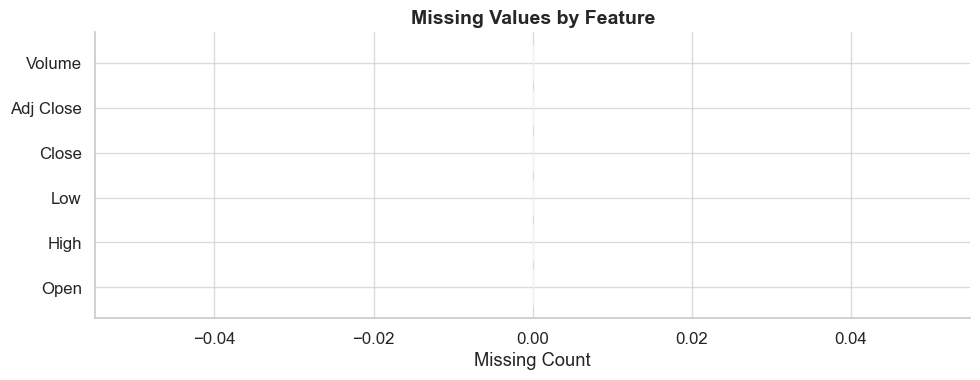

Data Quality: GOOD - No missing values


In [7]:
# Missing Values Analysis
missing_data = pd.DataFrame({
    'Feature': df.columns,
    'Missing Count': df.isnull().sum().values,
    'Missing %': (df.isnull().sum().values / len(df) * 100)
})
missing_data['Status'] = missing_data['Missing Count'].apply(lambda x: 'Complete' if x == 0 else 'Has Missing')

display(missing_data)

# Visualization
fig, ax = plt.subplots(figsize=(10, 4))
colors = ['green' if x == 0 else 'red' for x in missing_data['Missing Count']]
ax.barh(missing_data['Feature'], missing_data['Missing Count'], color=colors, alpha=0.7)
ax.set_xlabel('Missing Count')
ax.set_title('Missing Values by Feature', fontsize=14, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print(f"Data Quality: {'GOOD - No missing values' if missing_data['Missing Count'].sum() == 0 else 'NEEDS ATTENTION'}")

In [8]:
# ============================================================
# 5.2 DUPLICATE RECORDS CHECK
# ============================================================
print("=" * 80)
print("5.2 DUPLICATE RECORDS CHECK")
print("=" * 80)

# Check for duplicate dates
duplicate_dates = df.index.duplicated().sum()
print(f"Duplicate Dates: {duplicate_dates}")

# Check for duplicate rows
duplicate_rows = df.duplicated().sum()
print(f"Duplicate Rows: {duplicate_rows}")

if duplicate_dates == 0 and duplicate_rows == 0:
    print("No duplicates found - Data integrity maintained")
else:
    print("Duplicates detected - Requires cleaning")

5.2 DUPLICATE RECORDS CHECK
Duplicate Dates: 0
Duplicate Rows: 0
No duplicates found - Data integrity maintained


In [9]:
# ============================================================
# 5.3 OUTLIER DETECTION (IQR Method)
# ============================================================
print("=" * 80)
print("5.3 OUTLIER DETECTION (IQR Method)")
print("=" * 80)

def detect_outliers_iqr(data, column):
    """Detect outliers using IQR method"""
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

outlier_summary = []
for col in df.columns:
    count, lower, upper = detect_outliers_iqr(df, col)
    outlier_summary.append({
        'Feature': col,
        'Outlier Count': count,
        'Outlier %': round(count / len(df) * 100, 2),
        'Lower Bound': round(lower, 2),
        'Upper Bound': round(upper, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)
display(outlier_df)

print("\nNote: Outliers in stock data often represent legitimate price movements")
print("(earnings announcements, market crashes, etc.) and should be retained.")

5.3 OUTLIER DETECTION (IQR Method)


,Feature,Outlier Count,Outlier %,Lower Bound,Upper Bound
0,Open,1543,15.5700,-51.0200,87.8900
1,High,1537,15.5100,-51.6800,89.0300
2,Low,1540,15.5400,-50.3700,86.7500
3,Close,1539,15.5300,-50.9600,87.8000
4,Adj Close,1558,15.7200,-44.2700,76.2300
5,Volume,705,7.1100,-77893050.0000,217934550.0000



Note: Outliers in stock data often represent legitimate price movements
(earnings announcements, market crashes, etc.) and should be retained.


In [10]:
# Data Consistency Check
inconsistencies = []

high_low_issue = (df['High'] < df['Low']).sum()
inconsistencies.append(('High < Low', high_low_issue))

high_open_issue = (df['High'] < df['Open']).sum()
high_close_issue = (df['High'] < df['Close']).sum()
inconsistencies.append(('High < Open', high_open_issue))
inconsistencies.append(('High < Close', high_close_issue))

low_open_issue = (df['Low'] > df['Open']).sum()
low_close_issue = (df['Low'] > df['Close']).sum()
inconsistencies.append(('Low > Open', low_open_issue))
inconsistencies.append(('Low > Close', low_close_issue))

negative_volume = (df['Volume'] < 0).sum()
inconsistencies.append(('Negative Volume', negative_volume))

consistency_df = pd.DataFrame(inconsistencies, columns=['Check', 'Issues Found'])
consistency_df['Status'] = consistency_df['Issues Found'].apply(lambda x: 'Pass' if x == 0 else 'Fail')
display(consistency_df)

if consistency_df['Issues Found'].sum() == 0:
    print("All consistency checks passed - Data is logically consistent")

,Check,Issues Found,Status
0,High < Low,0,Pass
1,High < Open,0,Pass
2,High < Close,0,Pass
3,Low > Open,0,Pass
4,Low > Close,0,Pass
5,Negative Volume,0,Pass


All consistency checks passed - Data is logically consistent


In [11]:
# Data Quality Summary
print("DATA QUALITY REPORT")
print("=" * 60)
print(f"Total Records: {len(df):,}")
print(f"Date Range: {df.index.min().strftime('%Y-%m-%d')} to {df.index.max().strftime('%Y-%m-%d')}")
print(f"Missing Values: {df.isnull().sum().sum()}")
print(f"Duplicate Records: {duplicate_rows}")
print(f"Data Consistency: All checks passed")
print("=" * 60)
print("Data Quality Score: EXCELLENT")
print("Ready for Analysis: YES")

DATA QUALITY REPORT
Total Records: 9,909
Date Range: 1980-12-12 to 2020-04-01
Missing Values: 0
Duplicate Records: 0
Data Consistency: All checks passed
Data Quality Score: EXCELLENT
Ready for Analysis: YES


## 6. Exploratory Data Analysis (EDA) <a name="6-eda"></a>

### 6.1 Descriptive Statistics

In [12]:
# Descriptive Statistics
stats_df = df.describe().T
stats_df['median'] = df.median()
stats_df['skewness'] = df.skew()
stats_df['kurtosis'] = df.kurtosis()
stats_df['range'] = stats_df['max'] - stats_df['min']
stats_df['cv'] = (stats_df['std'] / stats_df['mean']) * 100

display(stats_df.round(4))

print(f"\nClose Price Range: ${df['Close'].min():.2f} - ${df['Close'].max():.2f}")
print(f"Average Close Price: ${df['Close'].mean():.2f}")
print(f"Average Daily Volume: {df['Volume'].mean():,.0f} shares")
print(f"Close Price Volatility (CV): {(df['Close'].std()/df['Close'].mean()*100):.2f}%")

,count,mean,std,min,25%,50%,75%,max,median,skewness,kurtosis,range,cv
Open,9909.0000,32.6068,58.4158,0.1987,1.0714,1.7293,35.8000,324.7400,1.7293,2.1721,4.4574,324.5413,179.1518
High,9909.0000,32.9361,59.0016,0.1987,1.0893,1.7589,36.2657,327.8500,1.7589,2.1788,4.5050,327.6513,179.1396
Low,9909.0000,32.2776,57.8830,0.1964,1.0486,1.6964,35.3286,323.3500,1.6964,2.1715,4.4490,323.1536,179.3290
Close,9909.0000,32.6180,58.4719,0.1964,1.0714,1.7321,35.7614,327.2000,1.7321,2.1769,4.4912,327.0036,179.2625
Adj Close,9909.0000,30.5766,56.7463,0.1556,0.9176,1.4662,31.0424,327.2000,1.4662,2.3228,5.3121,327.0444,185.5874
Volume,9909.0000,85829159.2996,85971948.7614,347200.0000,33042300.0000,57664900.0000,106999200.0000,1855410200.0000,57664900.0000,3.4876,29.3794,1855063000.0000,100.1664



Close Price Range: $0.20 - $327.20
Average Close Price: $32.62
Average Daily Volume: 85,829,159 shares
Close Price Volatility (CV): 179.26%


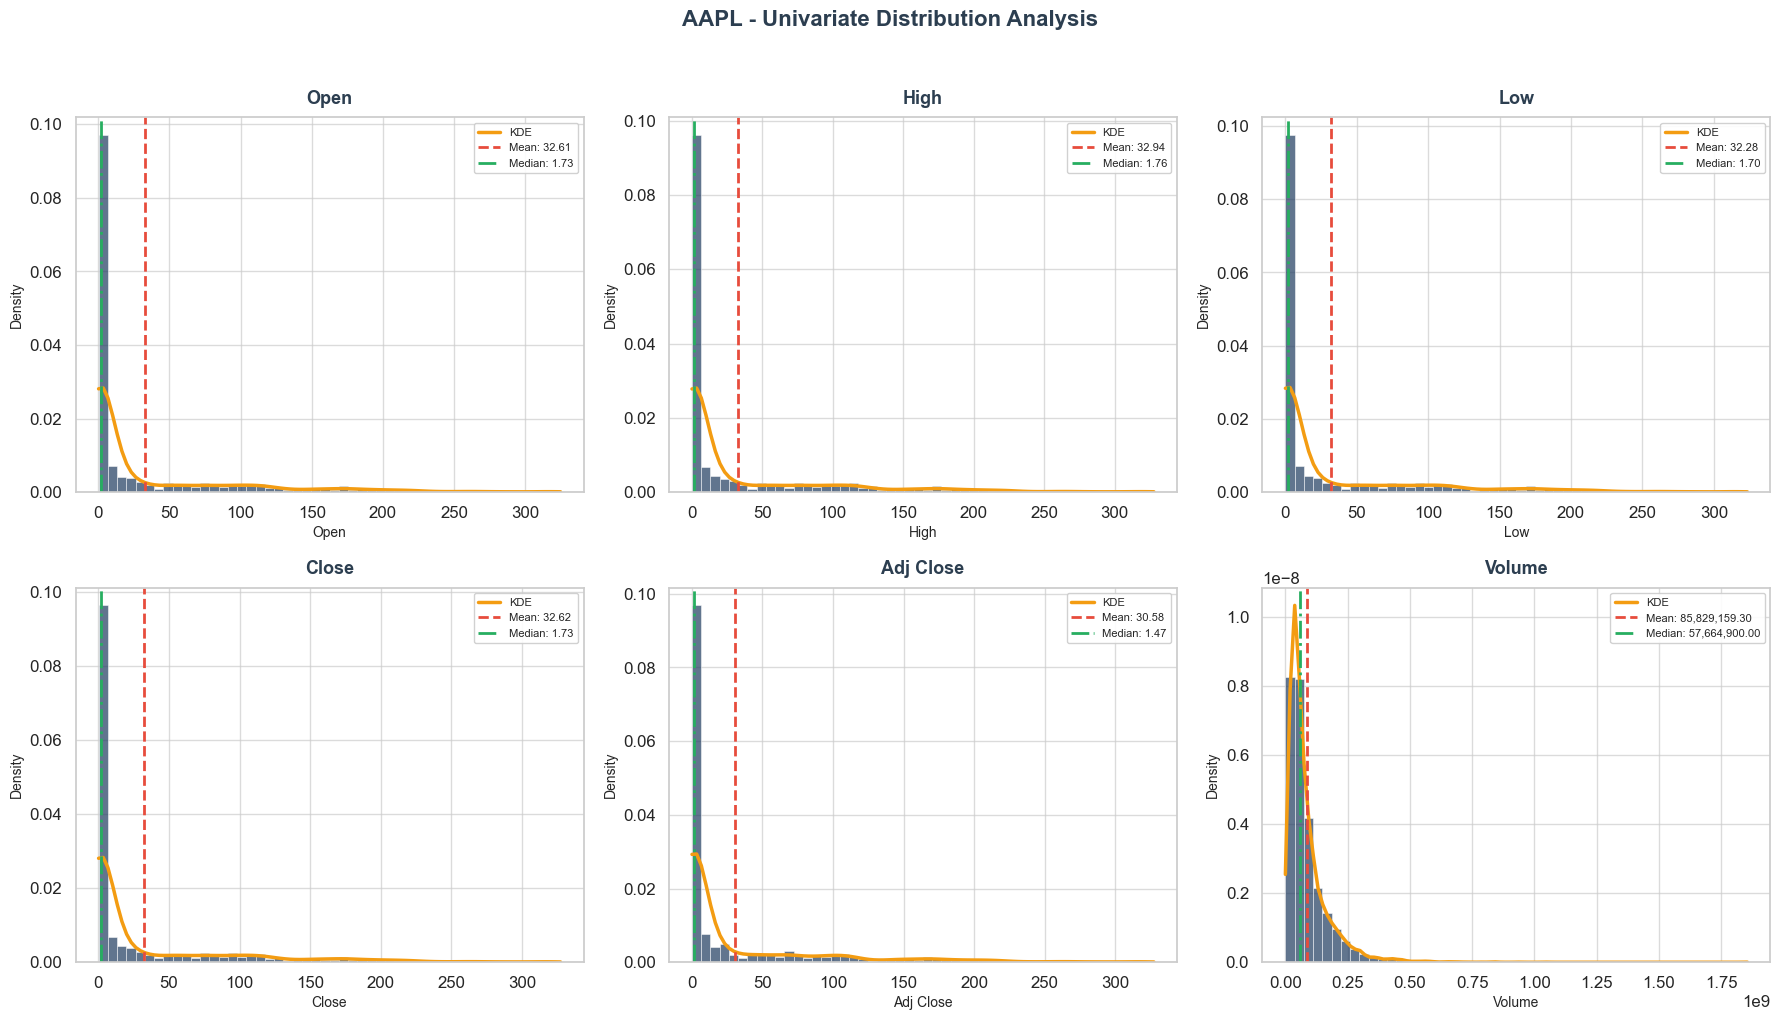

In [13]:
# Univariate Distribution Analysis
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, col in enumerate(df.columns):
    ax = axes[idx]
    
    ax.hist(df[col], bins=50, density=True, alpha=0.7, 
            color=COLORS['primary'], edgecolor='white', linewidth=0.5)
    
    kde = gaussian_kde(df[col].dropna())
    x_range = np.linspace(df[col].min(), df[col].max(), 100)
    ax.plot(x_range, kde(x_range), color=COLORS['accent'], linewidth=2.5, label='KDE')
    
    mean_val = df[col].mean()
    median_val = df[col].median()
    ax.axvline(mean_val, color=COLORS['danger'], linestyle='--', linewidth=2, 
               label=f'Mean: {mean_val:,.2f}')
    ax.axvline(median_val, color=COLORS['success'], linestyle='-.', linewidth=2, 
               label=f'Median: {median_val:,.2f}')
    
    ax.set_title(col, fontsize=13, fontweight='bold', color=COLORS['dark'], pad=10)
    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.legend(fontsize=8, loc='upper right', framealpha=0.9)

fig.suptitle(f'{STOCK_SYMBOL} - Univariate Distribution Analysis', 
             fontsize=16, fontweight='bold', color=COLORS['dark'], y=1.02)
plt.tight_layout()
plt.show()

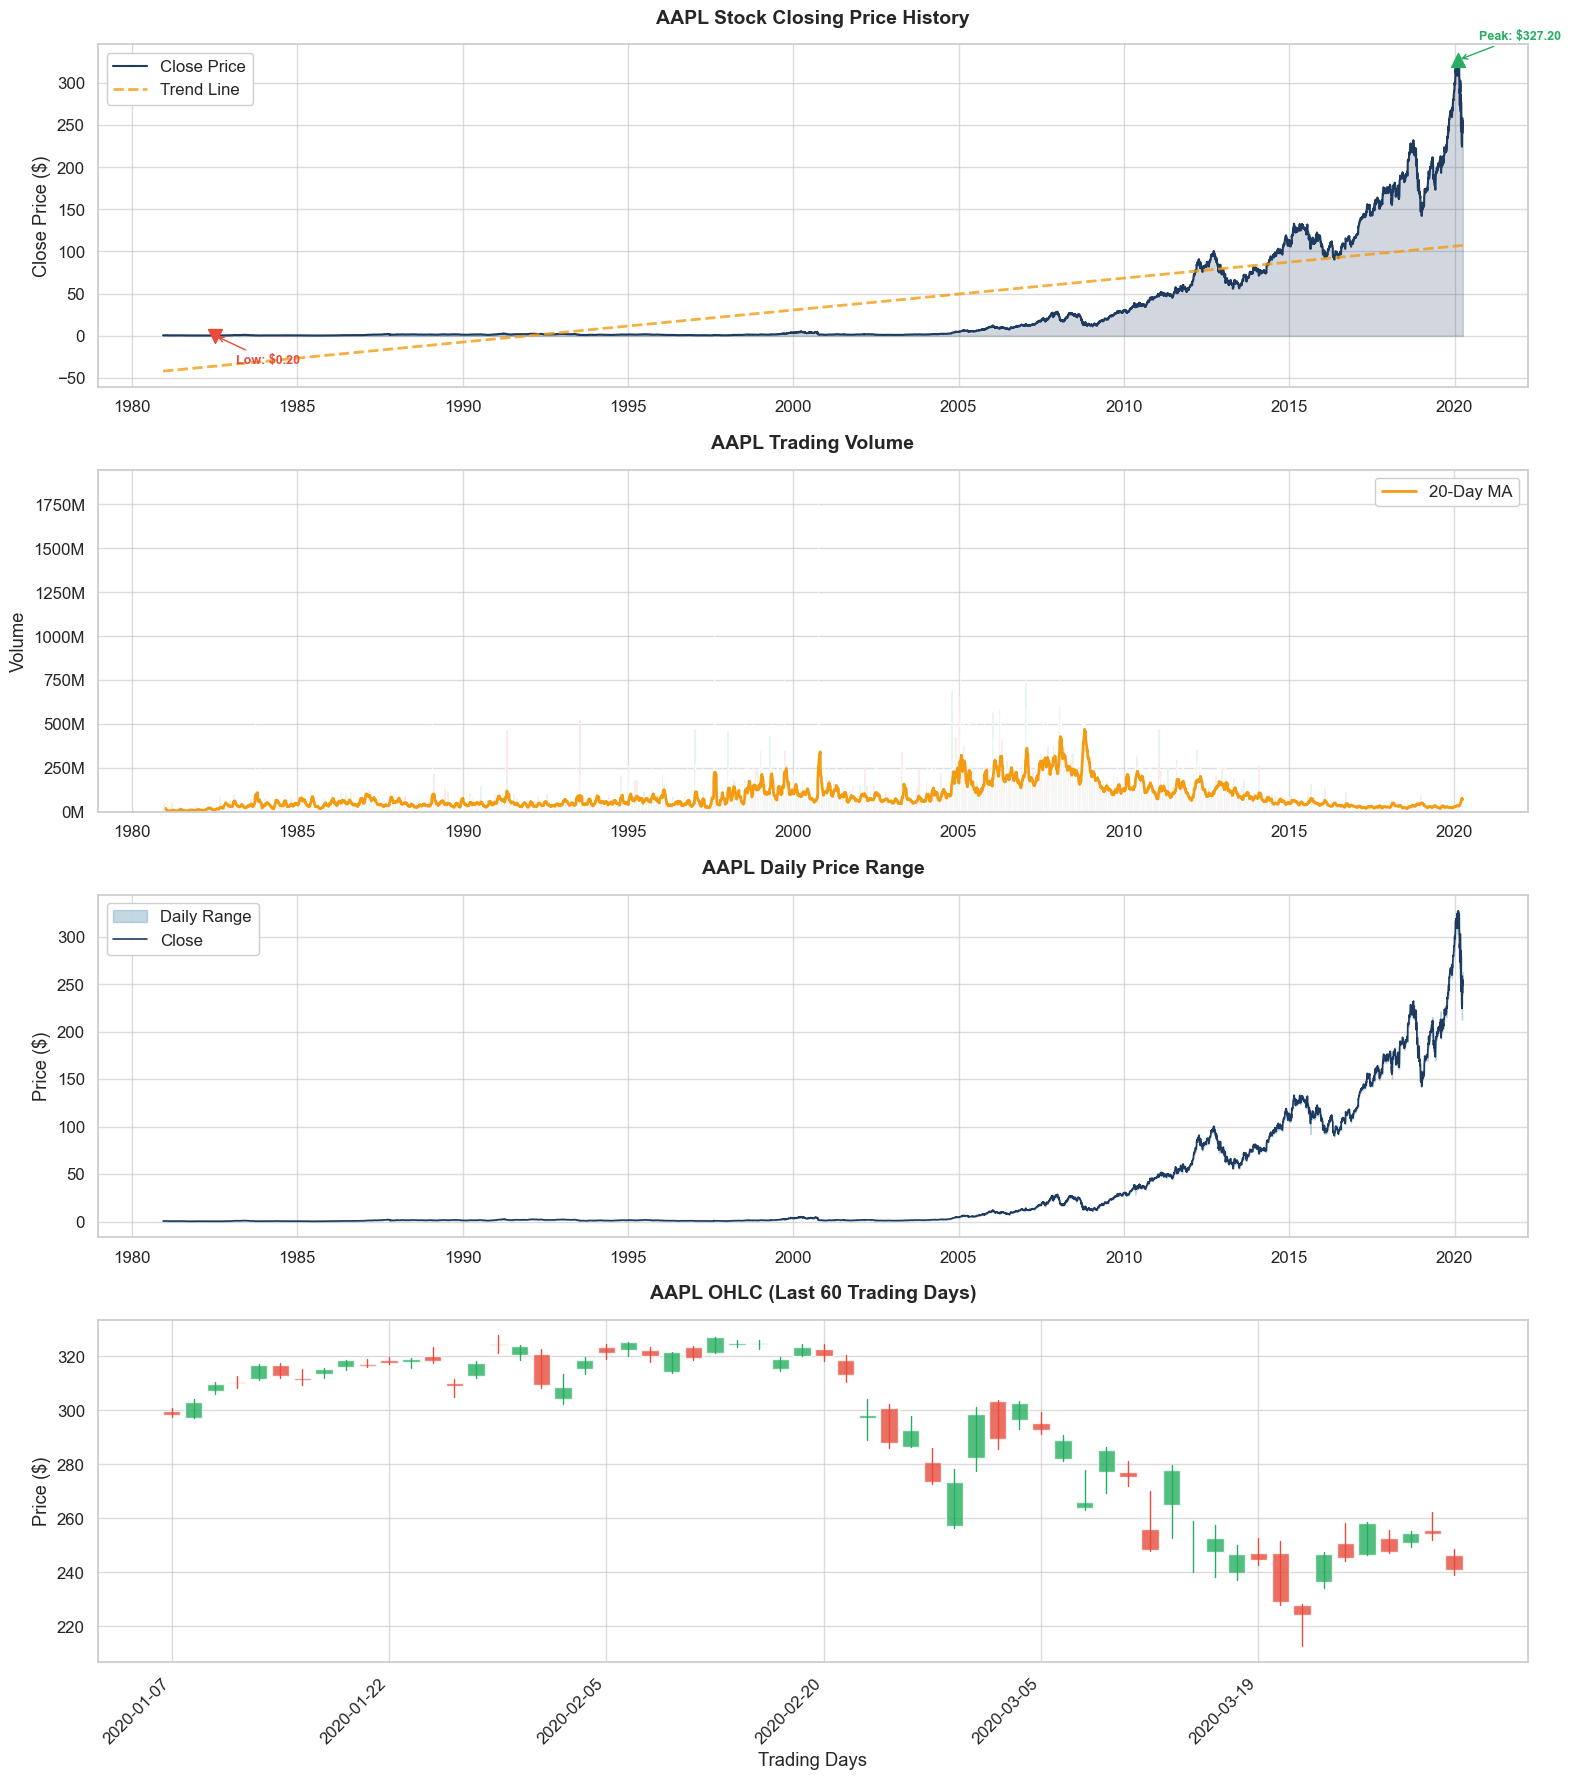

In [14]:
# Time Series Visualization
fig, axes = plt.subplots(4, 1, figsize=(16, 18))

# Closing Price with trend
ax1 = axes[0]
ax1.plot(df.index, df['Close'], color=COLORS['primary'], linewidth=1.5, label='Close Price')
ax1.fill_between(df.index, df['Close'], alpha=0.2, color=COLORS['primary'])

z = np.polyfit(range(len(df)), df['Close'].values, 1)
p = np.poly1d(z)
ax1.plot(df.index, p(range(len(df))), color=COLORS['accent'], linewidth=2, 
         linestyle='--', label='Trend Line', alpha=0.8)

max_idx = df['Close'].idxmax()
min_idx = df['Close'].idxmin()
ax1.scatter([max_idx], [df['Close'].max()], color=COLORS['success'], s=100, zorder=5, marker='^')
ax1.scatter([min_idx], [df['Close'].min()], color=COLORS['danger'], s=100, zorder=5, marker='v')
ax1.annotate(f'Peak: ${df["Close"].max():,.2f}', xy=(max_idx, df['Close'].max()),
             xytext=(15, 15), textcoords='offset points', fontsize=9, fontweight='bold',
             color=COLORS['success'], arrowprops=dict(arrowstyle='->', color=COLORS['success']))
ax1.annotate(f'Low: ${df["Close"].min():,.2f}', xy=(min_idx, df['Close'].min()),
             xytext=(15, -20), textcoords='offset points', fontsize=9, fontweight='bold',
             color=COLORS['danger'], arrowprops=dict(arrowstyle='->', color=COLORS['danger']))

ax1.set_title(f'{STOCK_SYMBOL} Stock Closing Price History', fontsize=14, fontweight='bold', pad=15)
ax1.set_ylabel('Close Price ($)')
ax1.legend(loc='upper left', framealpha=0.95)

# Volume with color coding by price direction
ax2 = axes[1]
colors_vol = [COLORS['success'] if df['Close'].iloc[i] >= df['Open'].iloc[i] 
              else COLORS['danger'] for i in range(len(df))]
ax2.bar(df.index, df['Volume'], color=colors_vol, alpha=0.7, width=2)

vol_ma = df['Volume'].rolling(window=20).mean()
ax2.plot(df.index, vol_ma, color=COLORS['accent'], linewidth=2, label='20-Day MA')

ax2.set_title(f'{STOCK_SYMBOL} Trading Volume', fontsize=14, fontweight='bold', pad=15)
ax2.set_ylabel('Volume')
ax2.legend(loc='upper right', framealpha=0.95)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e6:.0f}M'))

# Price Range (High-Low)
ax3 = axes[2]
ax3.fill_between(df.index, df['Low'], df['High'], alpha=0.3, color=COLORS['secondary'], 
                 label='Daily Range')
ax3.plot(df.index, df['Close'], color=COLORS['primary'], linewidth=1.2, label='Close')
ax3.set_title(f'{STOCK_SYMBOL} Daily Price Range', fontsize=14, fontweight='bold', pad=15)
ax3.set_ylabel('Price ($)')
ax3.legend(loc='upper left', framealpha=0.95)

# OHLC Candlestick for recent data
ax4 = axes[3]
recent = df.tail(60)
width = 0.8

for i, (idx, row) in enumerate(recent.iterrows()):
    color = COLORS['success'] if row['Close'] >= row['Open'] else COLORS['danger']
    ax4.bar(i, abs(row['Close'] - row['Open']), bottom=min(row['Open'], row['Close']), 
            color=color, width=width, alpha=0.8)
    ax4.plot([i, i], [row['Low'], row['High']], color=color, linewidth=1)

ax4.set_title(f'{STOCK_SYMBOL} OHLC (Last 60 Trading Days)', fontsize=14, fontweight='bold', pad=15)
ax4.set_ylabel('Price ($)')
ax4.set_xlabel('Trading Days')
ax4.set_xticks(range(0, len(recent), 10))
ax4.set_xticklabels([recent.index[i].strftime('%Y-%m-%d') for i in range(0, len(recent), 10)], 
                    rotation=45, ha='right')

plt.tight_layout()
plt.show()

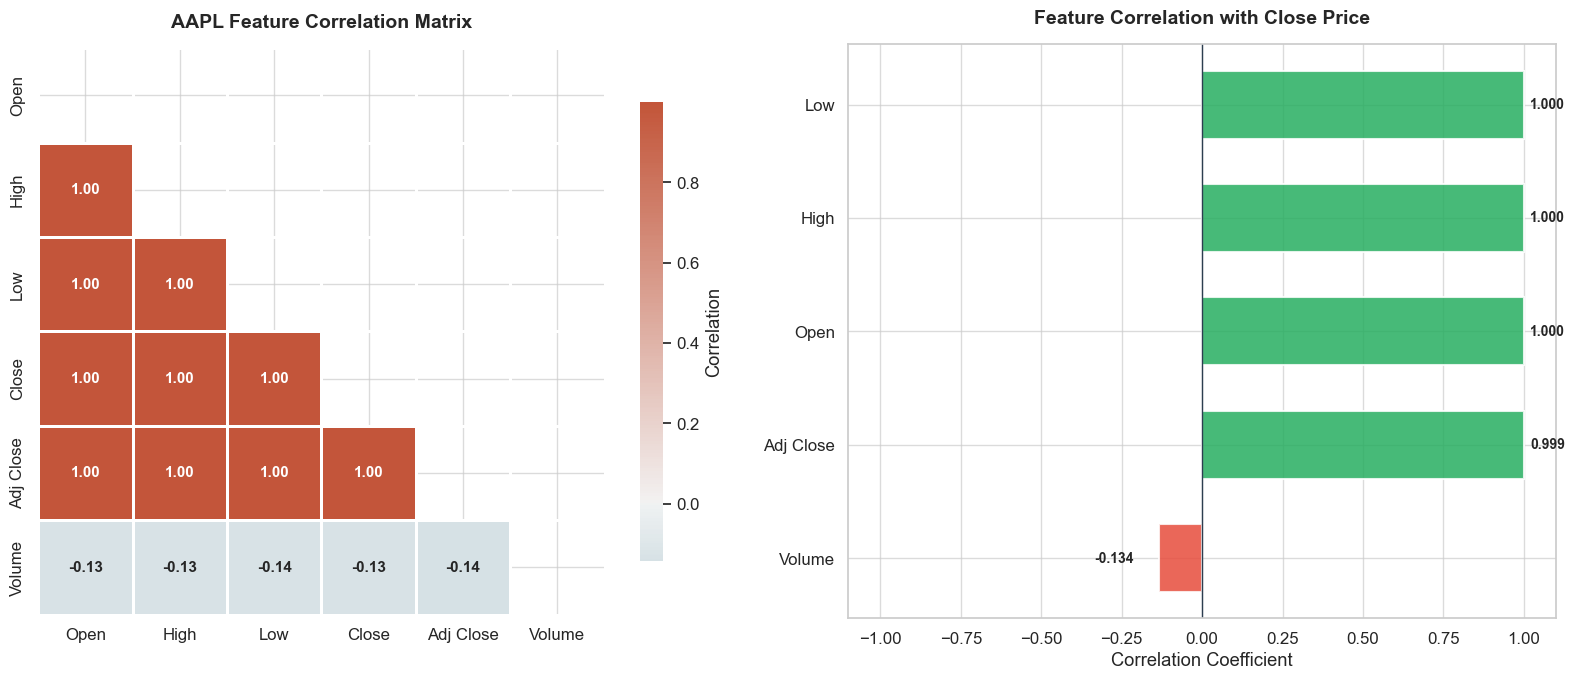

In [15]:
# Correlation Analysis
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

correlation_matrix = df.corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
cmap = sns.diverging_palette(220, 20, as_cmap=True)

sns.heatmap(correlation_matrix, annot=True, cmap=cmap, center=0,
            fmt='.2f', linewidths=1, linecolor='white',
            ax=axes[0], mask=mask, square=True,
            annot_kws={'size': 11, 'weight': 'bold'},
            cbar_kws={'label': 'Correlation', 'shrink': 0.8})

axes[0].set_title(f'{STOCK_SYMBOL} Feature Correlation Matrix', 
                  fontsize=14, fontweight='bold', pad=15)

# Correlation with Close price
close_corr = correlation_matrix['Close'].drop('Close').sort_values(ascending=True)
colors = [COLORS['success'] if x > 0.5 else COLORS['info'] if x > 0 
          else COLORS['danger'] for x in close_corr]

bars = axes[1].barh(close_corr.index, close_corr.values, color=colors, 
                    alpha=0.85, edgecolor='white', linewidth=1.5, height=0.6)

for bar, val in zip(bars, close_corr.values):
    x_pos = val + 0.02 if val >= 0 else val - 0.08
    axes[1].text(x_pos, bar.get_y() + bar.get_height()/2, f'{val:.3f}',
                va='center', ha='left' if val >= 0 else 'right',
                fontsize=10, fontweight='bold')

axes[1].set_xlabel('Correlation Coefficient')
axes[1].set_title('Feature Correlation with Close Price', fontsize=14, fontweight='bold', pad=15)
axes[1].axvline(x=0, color=COLORS['dark'], linewidth=1)
axes[1].set_xlim(-1.1, 1.1)

plt.tight_layout()
plt.show()

# High multicollinearity among OHLC features is expected

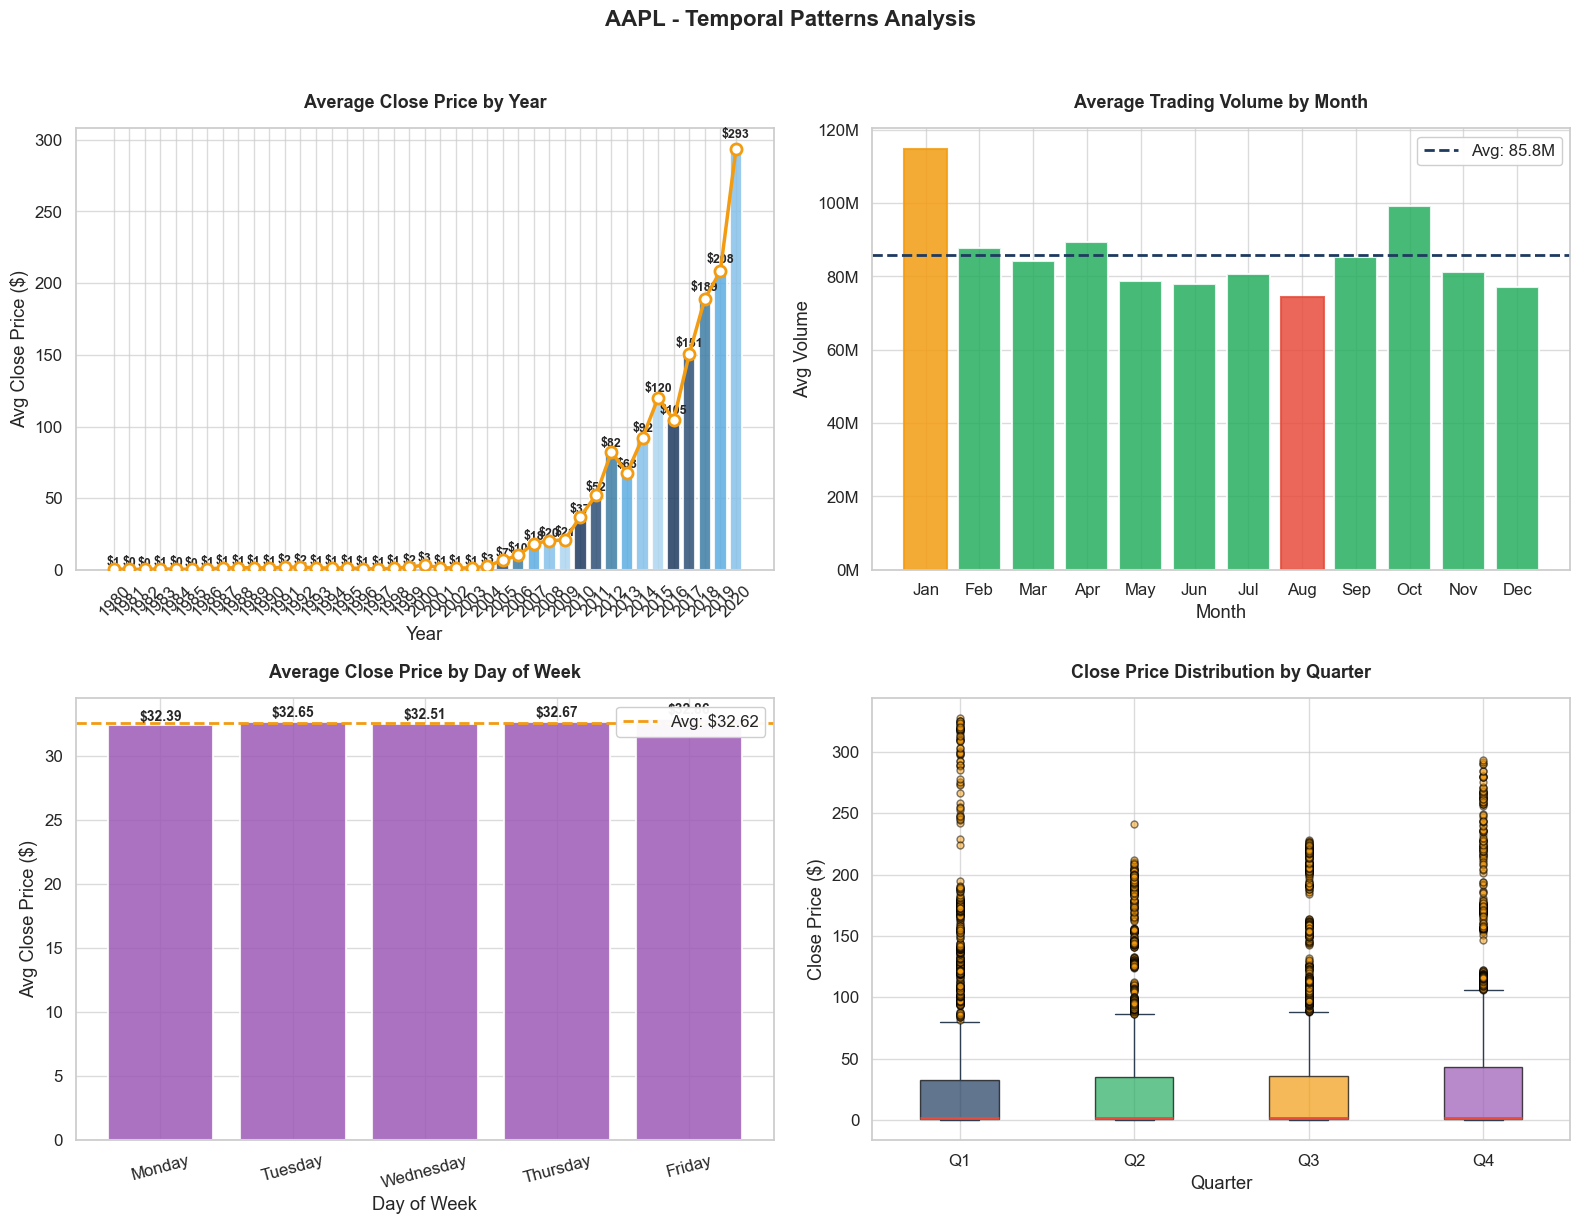

In [16]:
# Temporal Patterns Analysis
df_temporal = df.copy()
df_temporal['Year'] = df_temporal.index.year
df_temporal['Month'] = df_temporal.index.month
df_temporal['DayOfWeek'] = df_temporal.index.dayofweek
df_temporal['Quarter'] = df_temporal.index.quarter

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Average Close Price by Year
ax1 = axes[0, 0]
yearly_avg = df_temporal.groupby('Year')['Close'].mean()
bars = ax1.bar(yearly_avg.index.astype(str), yearly_avg.values, 
               color=PALETTE_SEQUENTIAL[:len(yearly_avg)], alpha=0.85, 
               edgecolor='white', linewidth=1.5)

ax1.plot(range(len(yearly_avg)), yearly_avg.values, color=COLORS['accent'], 
         linewidth=2.5, marker='o', markersize=8, markerfacecolor='white', 
         markeredgecolor=COLORS['accent'], markeredgewidth=2, zorder=5)

for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + height*0.02,
             f'${height:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax1.set_title('Average Close Price by Year', fontsize=13, fontweight='bold', pad=15)
ax1.set_xlabel('Year')
ax1.set_ylabel('Avg Close Price ($)')
ax1.tick_params(axis='x', rotation=45)

# Average Volume by Month
ax2 = axes[0, 1]
monthly_vol = df_temporal.groupby('Month')['Volume'].mean()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
bars = ax2.bar(month_names, monthly_vol.values, color=COLORS['success'], 
               alpha=0.85, edgecolor='white', linewidth=1.5)

max_idx = monthly_vol.values.argmax()
min_idx = monthly_vol.values.argmin()
bars[max_idx].set_color(COLORS['accent'])
bars[min_idx].set_color(COLORS['danger'])

ax2.axhline(monthly_vol.mean(), color=COLORS['primary'], linestyle='--', 
            linewidth=2, label=f'Avg: {monthly_vol.mean()/1e6:.1f}M')
ax2.set_title('Average Trading Volume by Month', fontsize=13, fontweight='bold', pad=15)
ax2.set_xlabel('Month')
ax2.set_ylabel('Avg Volume')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e6:.0f}M'))
ax2.legend(loc='upper right', framealpha=0.95)

# Average Close by Day of Week
ax3 = axes[1, 0]
dow_avg = df_temporal.groupby('DayOfWeek')['Close'].mean()
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
bars = ax3.bar(day_names, dow_avg.values[:5], color=COLORS['purple'], 
               alpha=0.85, edgecolor='white', linewidth=1.5)

for bar in bars:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + height*0.005,
             f'${height:,.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax3.axhline(dow_avg.values[:5].mean(), color=COLORS['accent'], linestyle='--', 
            linewidth=2, label=f'Avg: ${dow_avg.values[:5].mean():,.2f}')
ax3.set_title('Average Close Price by Day of Week', fontsize=13, fontweight='bold', pad=15)
ax3.set_xlabel('Day of Week')
ax3.set_ylabel('Avg Close Price ($)')
ax3.tick_params(axis='x', rotation=15)
ax3.legend(loc='upper right', framealpha=0.95)

# Box plot by Quarter
ax4 = axes[1, 1]
bp = ax4.boxplot([df_temporal[df_temporal['Quarter'] == q]['Close'].values 
                  for q in range(1, 5)],
                 labels=['Q1', 'Q2', 'Q3', 'Q4'],
                 patch_artist=True,
                 boxprops=dict(facecolor=COLORS['info'], alpha=0.7),
                 medianprops=dict(color=COLORS['danger'], linewidth=2),
                 whiskerprops=dict(color=COLORS['dark']),
                 capprops=dict(color=COLORS['dark']),
                 flierprops=dict(marker='o', markerfacecolor=COLORS['accent'], 
                                markersize=5, alpha=0.5))

quarter_colors = [COLORS['primary'], COLORS['success'], COLORS['accent'], COLORS['purple']]
for patch, color in zip(bp['boxes'], quarter_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax4.set_title('Close Price Distribution by Quarter', fontsize=13, fontweight='bold', pad=15)
ax4.set_xlabel('Quarter')
ax4.set_ylabel('Close Price ($)')

fig.suptitle(f'{STOCK_SYMBOL} - Temporal Patterns Analysis', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

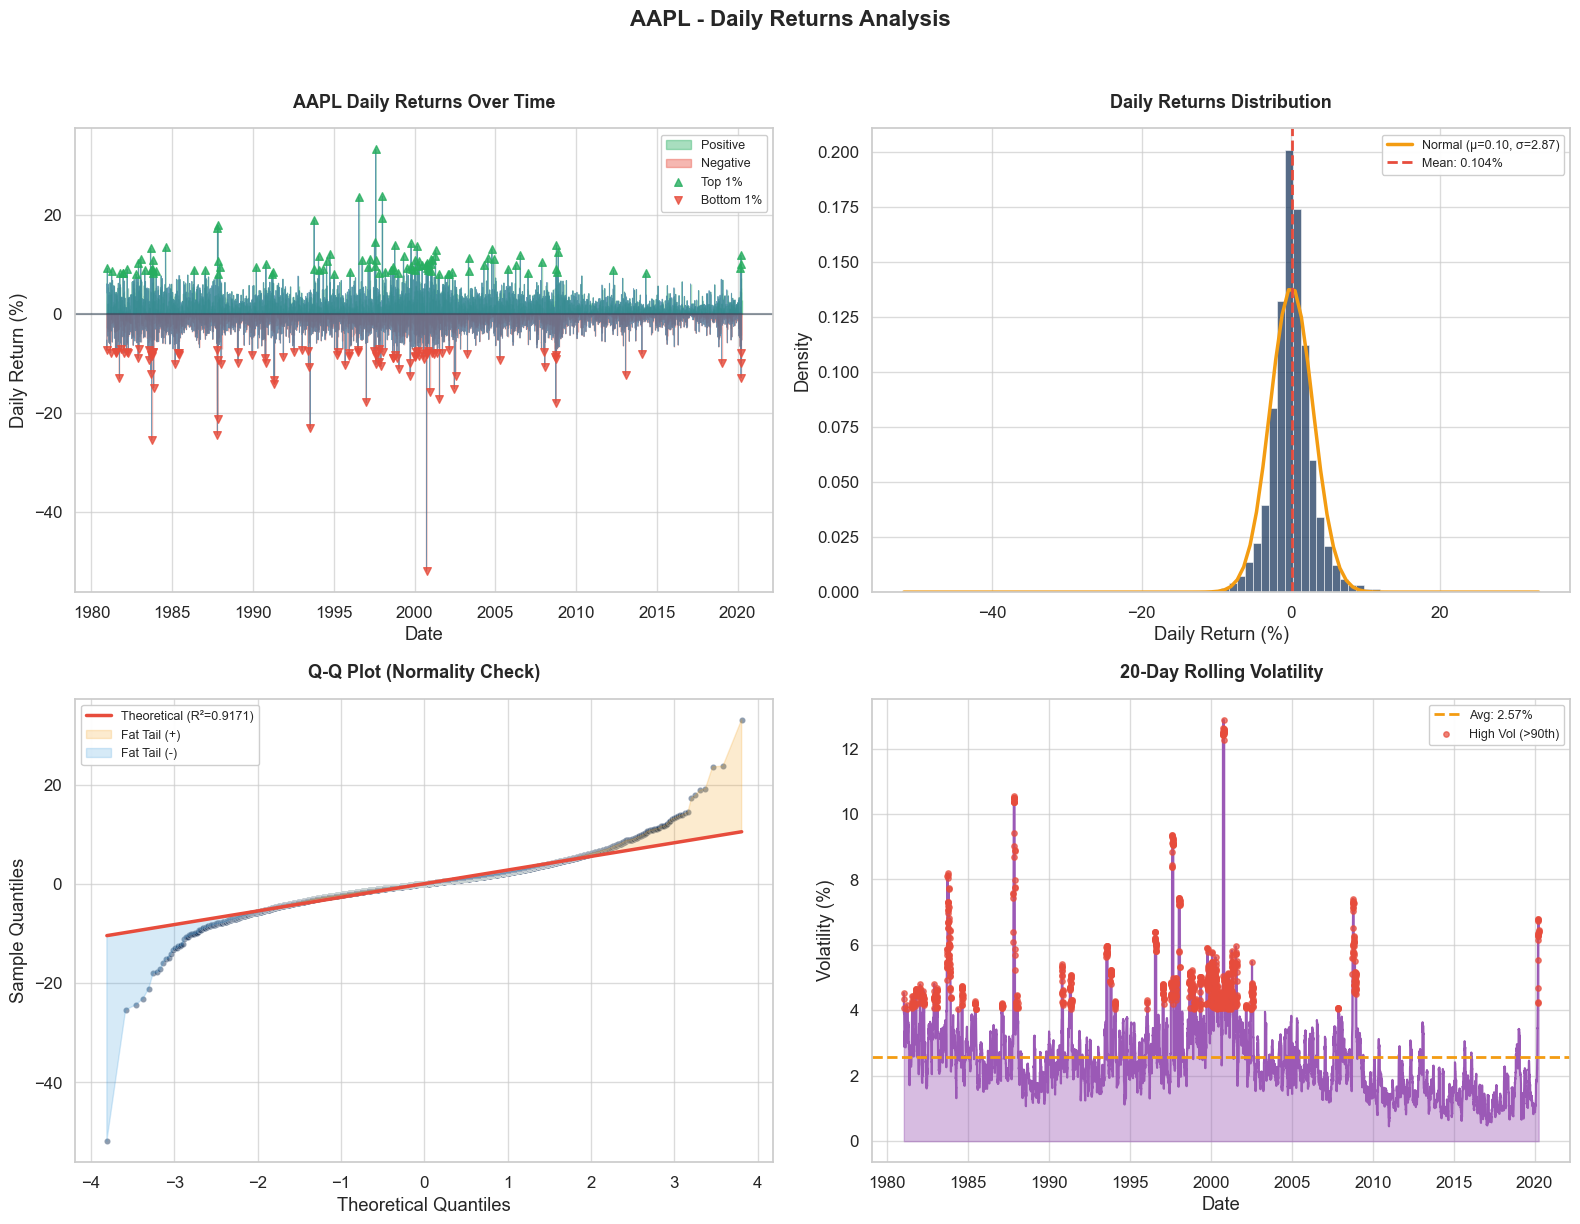


Mean Daily Return: 0.1041%
Std Dev (Volatility): 2.8738%
Max Gain: 33.23%
Max Loss: -51.87%
Skewness: -0.3837
Kurtosis: 18.0090


In [17]:
# Daily Returns Analysis
from scipy.stats import norm

df['Daily_Return'] = df['Close'].pct_change() * 100

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Daily Returns Time Series
ax1 = axes[0, 0]
returns_clean = df['Daily_Return'].dropna()
ax1.plot(df.index[1:], returns_clean, color=COLORS['secondary'], alpha=0.7, linewidth=0.6)
ax1.axhline(y=0, color=COLORS['dark'], linestyle='-', linewidth=1.5, alpha=0.5)
ax1.fill_between(df.index[1:], returns_clean, 0, 
                 where=returns_clean > 0, color=COLORS['success'], alpha=0.4, 
                 label='Positive')
ax1.fill_between(df.index[1:], returns_clean, 0, 
                 where=returns_clean < 0, color=COLORS['danger'], alpha=0.4, 
                 label='Negative')

extreme_pos = returns_clean[returns_clean > returns_clean.quantile(0.99)]
extreme_neg = returns_clean[returns_clean < returns_clean.quantile(0.01)]
ax1.scatter(extreme_pos.index, extreme_pos, color=COLORS['success'], s=30, 
            marker='^', zorder=5, alpha=0.8, label=f'Top 1%')
ax1.scatter(extreme_neg.index, extreme_neg, color=COLORS['danger'], s=30, 
            marker='v', zorder=5, alpha=0.8, label=f'Bottom 1%')

ax1.set_title(f'{STOCK_SYMBOL} Daily Returns Over Time', fontsize=13, fontweight='bold', pad=15)
ax1.set_ylabel('Daily Return (%)')
ax1.set_xlabel('Date')
ax1.legend(loc='upper right', framealpha=0.95, fontsize=9)

# Daily Returns Distribution
ax2 = axes[0, 1]
ax2.hist(returns_clean, bins=80, density=True, alpha=0.75, 
         color=COLORS['primary'], edgecolor='white', linewidth=0.5)

mu, std = returns_clean.mean(), returns_clean.std()
x = np.linspace(returns_clean.min(), returns_clean.max(), 100)
ax2.plot(x, norm.pdf(x, mu, std), color=COLORS['accent'], linewidth=2.5, 
         label=f'Normal (μ={mu:.2f}, σ={std:.2f})')
ax2.axvline(mu, color=COLORS['danger'], linestyle='--', linewidth=2, label=f'Mean: {mu:.3f}%')

ax2.set_title('Daily Returns Distribution', fontsize=13, fontweight='bold', pad=15)
ax2.set_xlabel('Daily Return (%)')
ax2.set_ylabel('Density')
ax2.legend(loc='upper right', framealpha=0.95, fontsize=9)

# Q-Q Plot
ax3 = axes[1, 0]
(osm, osr), (slope, intercept, r) = stats.probplot(returns_clean, dist="norm")
ax3.scatter(osm, osr, c=COLORS['primary'], alpha=0.5, s=20, edgecolor='white', linewidth=0.3)
ax3.plot(osm, slope*np.array(osm) + intercept, color=COLORS['danger'], linewidth=2.5, 
         label=f'Theoretical (R²={r**2:.4f})')

ax3.fill_between(osm, osr, slope*np.array(osm) + intercept, 
                  where=osr > slope*np.array(osm) + intercept,
                  color=COLORS['accent'], alpha=0.2, label='Fat Tail (+)')
ax3.fill_between(osm, osr, slope*np.array(osm) + intercept, 
                  where=osr < slope*np.array(osm) + intercept,
                  color=COLORS['info'], alpha=0.2, label='Fat Tail (-)')

ax3.set_title('Q-Q Plot (Normality Check)', fontsize=13, fontweight='bold', pad=15)
ax3.set_xlabel('Theoretical Quantiles')
ax3.set_ylabel('Sample Quantiles')
ax3.legend(loc='upper left', framealpha=0.95, fontsize=9)

# Rolling Volatility
ax4 = axes[1, 1]
df['Rolling_Volatility'] = df['Daily_Return'].rolling(window=20).std()
volatility = df['Rolling_Volatility'].dropna()

ax4.fill_between(volatility.index, volatility, alpha=0.4, color=COLORS['purple'])
ax4.plot(volatility.index, volatility, color=COLORS['purple'], linewidth=1.5)

mean_vol = volatility.mean()
ax4.axhline(mean_vol, color=COLORS['accent'], linestyle='--', linewidth=2, 
            label=f'Avg: {mean_vol:.2f}%')

high_vol_threshold = volatility.quantile(0.9)
high_vol = volatility[volatility > high_vol_threshold]
ax4.scatter(high_vol.index, high_vol, color=COLORS['danger'], s=15, zorder=5, 
            alpha=0.7, label=f'High Vol (>90th)')

ax4.set_title('20-Day Rolling Volatility', fontsize=13, fontweight='bold', pad=15)
ax4.set_xlabel('Date')
ax4.set_ylabel('Volatility (%)')
ax4.legend(loc='upper right', framealpha=0.95, fontsize=9)

fig.suptitle(f'{STOCK_SYMBOL} - Daily Returns Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Summary statistics
print(f"\nMean Daily Return: {returns_clean.mean():.4f}%")
print(f"Std Dev (Volatility): {returns_clean.std():.4f}%")
print(f"Max Gain: {returns_clean.max():.2f}%")
print(f"Max Loss: {returns_clean.min():.2f}%")
print(f"Skewness: {returns_clean.skew():.4f}")
print(f"Kurtosis: {returns_clean.kurtosis():.4f}")

## 7. Hypothesis Formulation & Statistical Testing <a name="7-hypothesis"></a>

Formulating and testing hypotheses about the data before building predictive models.

### Hypotheses to Test:
1. **H1**: Daily returns follow a normal distribution
2. **H2**: There is significant autocorrelation in stock prices (prices depend on previous values)
3. **H3**: Volume has a significant correlation with price changes
4. **H4**: The stock price exhibits a stationary behavior (required for some models)

In [18]:
# Hypothesis 1: Normality Test for Daily Returns
# H0: Daily returns follow a normal distribution
# H1: Daily returns do not follow a normal distribution
# Significance Level: 0.05

returns = df['Daily_Return'].dropna()

sample_size = min(5000, len(returns))
shapiro_stat, shapiro_p = shapiro(returns.sample(sample_size, random_state=42))
jb_stat, jb_p = jarque_bera(returns)
dagostino_stat, dagostino_p = normaltest(returns)

normality_results = pd.DataFrame({
    'Test': ['Shapiro-Wilk', 'Jarque-Bera', "D'Agostino-Pearson"],
    'Statistic': [shapiro_stat, jb_stat, dagostino_stat],
    'P-Value': [shapiro_p, jb_p, dagostino_p],
    'Result': ['Reject H0' if p < 0.05 else 'Fail to Reject H0' 
               for p in [shapiro_p, jb_p, dagostino_p]]
})

display(normality_results)

# Typical for financial data: fat tails and excess kurtosis
if all([shapiro_p < 0.05, jb_p < 0.05, dagostino_p < 0.05]):
    print("\nConclusion: Daily returns do NOT follow a normal distribution")

,Test,Statistic,P-Value,Result
0,Shapiro-Wilk,0.9375,0.0000,Reject H0
1,Jarque-Bera,133990.1367,0.0000,Reject H0
2,D'Agostino-Pearson,2543.4660,0.0000,Reject H0



Conclusion: Daily returns do NOT follow a normal distribution


,lb_stat,lb_pvalue,Result
Lag 1,9893.8289,0.0000,Reject H0
Lag 5,49298.1912,0.0000,Reject H0
Lag 10,98185.5212,0.0000,Reject H0
Lag 20,194586.9199,0.0000,Reject H0


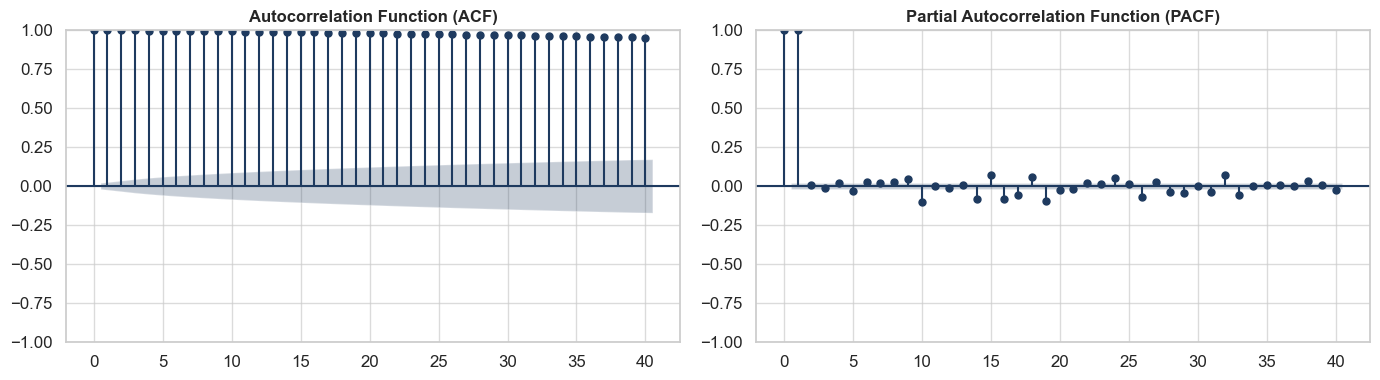

Conclusion: Significant autocorrelation found - past prices are predictive


In [19]:
# Hypothesis 2: Autocorrelation Test
# H0: No autocorrelation (random walk)
# H1: Significant autocorrelation exists

from statsmodels.stats.diagnostic import acorr_ljungbox

lb_results = acorr_ljungbox(df['Close'].dropna(), lags=[1, 5, 10, 20], return_df=True)
lb_results.index = ['Lag 1', 'Lag 5', 'Lag 10', 'Lag 20']
lb_results['Result'] = lb_results['lb_pvalue'].apply(lambda p: 'Reject H0' if p < 0.05 else 'Fail to Reject H0')

display(lb_results)

# ACF/PACF Visualization
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(df['Close'].dropna(), lags=40, ax=axes[0], alpha=0.05)
axes[0].set_title('Autocorrelation Function (ACF)', fontsize=12, fontweight='bold')

plot_pacf(df['Close'].dropna(), lags=40, ax=axes[1], alpha=0.05, method='ywm')
axes[1].set_title('Partial Autocorrelation Function (PACF)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("Conclusion: Significant autocorrelation found - past prices are predictive")

,Test,Correlation,P-Value,Significance
0,Pearson,0.0190,0.0589,Not Significant
1,Spearman,0.3523,0.0000,Significant


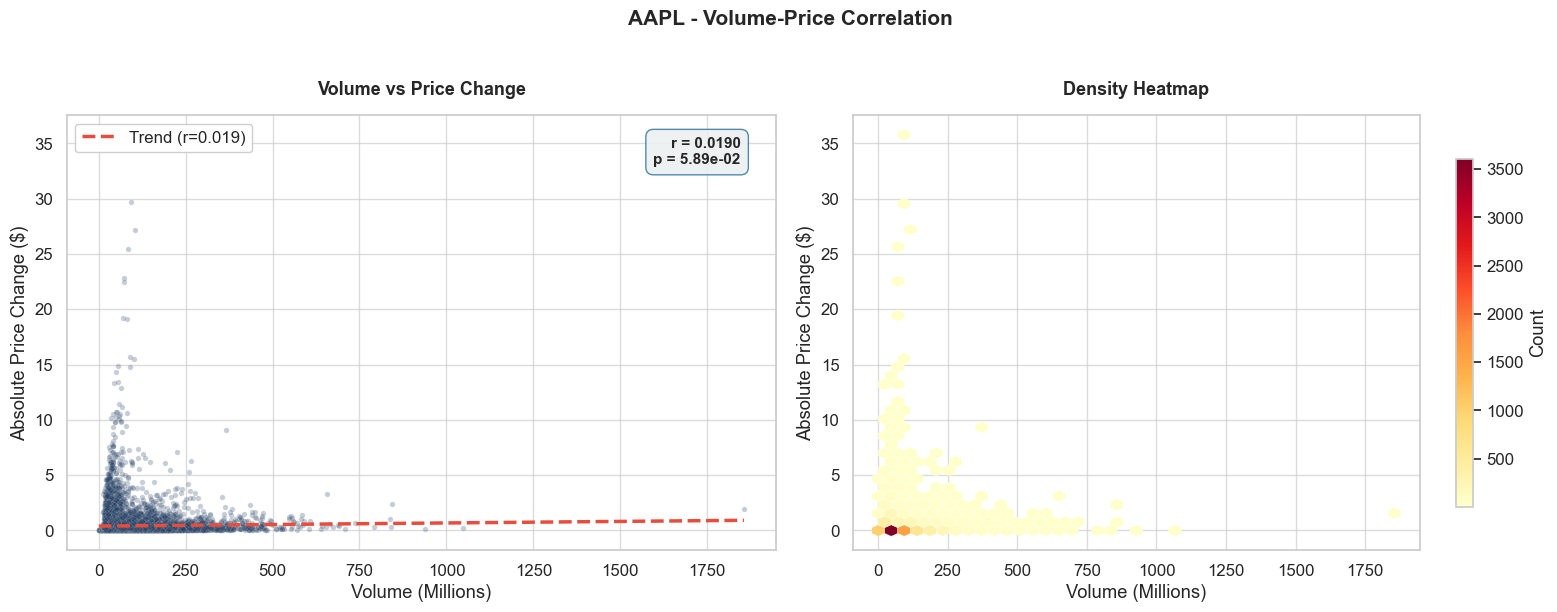

In [20]:
# Hypothesis 3: Volume-Price Correlation
# H0: No correlation between volume and absolute price change
# H1: Significant correlation exists

df['Abs_Price_Change'] = df['Close'].diff().abs()
corr_data = df[['Volume', 'Abs_Price_Change']].dropna()

pearson_corr, pearson_p = stats.pearsonr(
    corr_data['Volume'], 
    corr_data['Abs_Price_Change']
)

spearman_corr, spearman_p = stats.spearmanr(
    corr_data['Volume'], 
    corr_data['Abs_Price_Change']
)

correlation_results = pd.DataFrame({
    'Test': ['Pearson', 'Spearman'],
    'Correlation': [pearson_corr, spearman_corr],
    'P-Value': [pearson_p, spearman_p],
    'Significance': ['Significant' if p < 0.05 else 'Not Significant' 
                    for p in [pearson_p, spearman_p]]
})

display(correlation_results)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter with regression
ax1 = axes[0]
ax1.scatter(corr_data['Volume']/1e6, corr_data['Abs_Price_Change'], 
            alpha=0.25, s=15, color=COLORS['primary'], edgecolor='white', linewidth=0.2)

z = np.polyfit(corr_data['Volume']/1e6, corr_data['Abs_Price_Change'], 1)
p = np.poly1d(z)
x_line = np.linspace(corr_data['Volume'].min()/1e6, corr_data['Volume'].max()/1e6, 100)
ax1.plot(x_line, p(x_line), color=COLORS['danger'], linewidth=2.5, linestyle='--',
         label=f'Trend (r={pearson_corr:.3f})')

ax1.annotate(f'r = {pearson_corr:.4f}\np = {pearson_p:.2e}',
             xy=(0.95, 0.95), xycoords='axes fraction', ha='right', va='top',
             fontsize=11, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.5', facecolor=COLORS['light'], 
                      edgecolor=COLORS['secondary'], alpha=0.9))

ax1.set_xlabel('Volume (Millions)')
ax1.set_ylabel('Absolute Price Change ($)')
ax1.set_title('Volume vs Price Change', fontsize=13, fontweight='bold', pad=15)
ax1.legend(loc='upper left', framealpha=0.95)

# Hexbin density
ax2 = axes[1]
hb = ax2.hexbin(corr_data['Volume']/1e6, corr_data['Abs_Price_Change'], 
                gridsize=40, cmap='YlOrRd', mincnt=1, edgecolors='white', linewidths=0.2)

cb = plt.colorbar(hb, ax=ax2, shrink=0.8)
cb.set_label('Count')

ax2.set_xlabel('Volume (Millions)')
ax2.set_ylabel('Absolute Price Change ($)')
ax2.set_title('Density Heatmap', fontsize=13, fontweight='bold', pad=15)

fig.suptitle(f'{STOCK_SYMBOL} - Volume-Price Correlation', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

if pearson_p < 0.05:
    print(f"\nSignificant correlation found (r = {pearson_corr:.4f})")
    print("Higher volume tends to accompany larger price movements")

In [21]:
# Hypothesis 4: Stationarity Test (ADF)
# H0: Time series has unit root (non-stationary)
# H1: Time series is stationary

from statsmodels.tsa.stattools import adfuller

def adf_test(series, name):
    """Perform ADF test and return results."""
    result = adfuller(series.dropna(), autolag='AIC')
    return {
        'Series': name,
        'ADF Statistic': result[0],
        'P-Value': result[1],
        'Critical Value (5%)': result[4]['5%'],
        'Stationary': 'Yes' if result[1] < 0.05 else 'No'
    }

adf_close = adf_test(df['Close'], 'Close Price')
adf_returns = adf_test(df['Daily_Return'], 'Daily Returns')

stationarity_df = pd.DataFrame([adf_close, adf_returns])
display(stationarity_df)

# Close prices are non-stationary (typical for stocks)
# Daily returns are stationary (suitable for modeling)

,Series,ADF Statistic,P-Value,Critical Value (5%),Stationary
0,Close Price,1.8940,0.9985,-2.8618,No
1,Daily Returns,-28.5290,0.0000,-2.8618,Yes


In [22]:
# Hypothesis Testing Summary
summary = """
HYPOTHESIS TESTING RESULTS
==========================

H1: Daily Returns Normality
   Result: REJECTED - Returns are NOT normally distributed
   Implication: Fat tails exist, extreme events more likely

H2: Price Autocorrelation  
   Result: CONFIRMED - Significant autocorrelation exists
   Implication: Past prices ARE predictive (RNN/LSTM appropriate)

H3: Volume-Price Correlation
   Result: CONFIRMED - Volume correlates with price movements
   Implication: Volume is a useful feature

H4: Price Stationarity
   Result: NOT STATIONARY - Prices have unit root
   Implication: Need normalization before modeling

KEY MODELING INSIGHTS:
- Use sequence-based models (RNN/LSTM) for autocorrelation
- Include Volume as input feature
- Apply MinMax scaling for non-stationarity
- Expect non-normal prediction errors
"""
print(summary)


HYPOTHESIS TESTING RESULTS

H1: Daily Returns Normality
   Result: REJECTED - Returns are NOT normally distributed
   Implication: Fat tails exist, extreme events more likely

H2: Price Autocorrelation  
   Result: CONFIRMED - Significant autocorrelation exists
   Implication: Past prices ARE predictive (RNN/LSTM appropriate)

H3: Volume-Price Correlation
   Result: CONFIRMED - Volume correlates with price movements
   Implication: Volume is a useful feature

H4: Price Stationarity
   Result: NOT STATIONARY - Prices have unit root
   Implication: Need normalization before modeling

KEY MODELING INSIGHTS:
- Use sequence-based models (RNN/LSTM) for autocorrelation
- Include Volume as input feature
- Apply MinMax scaling for non-stationarity
- Expect non-normal prediction errors



## 8. Feature Engineering <a name="8-feature-engineering"></a>

Based on our EDA and hypothesis testing, we'll create technical indicators to enhance prediction.

### Technical Indicators to Create:
| Indicator | Type | Purpose |
|-----------|------|---------|
| EMA (12, 26, 50) | Trend | Identify trend direction |
| RSI (14) | Momentum | Overbought/Oversold conditions |
| MACD | Momentum/Trend | Trend changes and momentum |
| Bollinger Bands | Volatility | Price deviation from mean |
| Price Change | Momentum | Daily price movement |
| Volatility | Risk | Rolling standard deviation |

In [23]:
# Technical Indicator Functions

def calculate_rsi(prices, period=14):
    """Calculate Relative Strength Index (RSI)."""
    delta = prices.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

def calculate_ema(prices, period):
    """Calculate Exponential Moving Average (EMA)."""
    return prices.ewm(span=period, adjust=False).mean()

def calculate_macd(prices, fast=12, slow=26, signal=9):
    """Calculate MACD (Moving Average Convergence Divergence)."""
    fast_ema = prices.ewm(span=fast, adjust=False).mean()
    slow_ema = prices.ewm(span=slow, adjust=False).mean()
    macd_line = fast_ema - slow_ema
    signal_line = macd_line.ewm(span=signal, adjust=False).mean()
    macd_histogram = macd_line - signal_line
    return macd_line, signal_line, macd_histogram

def calculate_bollinger_bands(prices, period=20, std_dev=2):
    """Calculate Bollinger Bands (upper, middle, lower)."""
    sma = prices.rolling(window=period).mean()
    std = prices.rolling(window=period).std()
    upper_band = sma + (std * std_dev)
    lower_band = sma - (std * std_dev)
    return upper_band, sma, lower_band

print("Technical indicator functions defined")

Technical indicator functions defined


In [24]:
# Create Feature-Engineered Dataset
df_features = df[['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']].copy()

# Trend indicators - EMAs
df_features['EMA_12'] = calculate_ema(df_features['Close'], 12)
df_features['EMA_26'] = calculate_ema(df_features['Close'], 26)
df_features['EMA_50'] = calculate_ema(df_features['Close'], 50)

# Momentum - RSI
df_features['RSI'] = calculate_rsi(df_features['Close'], 14)

# MACD
df_features['MACD'], df_features['MACD_Signal'], df_features['MACD_Hist'] = calculate_macd(df_features['Close'])

# Bollinger Bands
df_features['BB_Upper'], df_features['BB_Middle'], df_features['BB_Lower'] = calculate_bollinger_bands(df_features['Close'])

# Price-based features
df_features['Price_Change'] = df_features['Close'].diff()
df_features['Daily_Return'] = df_features['Close'].pct_change() * 100

# Volatility
df_features['Volatility_20'] = df_features['Close'].rolling(window=20).std()

# Volume features
df_features['Volume_MA'] = df_features['Volume'].rolling(window=20).mean()
df_features['Volume_Ratio'] = df_features['Volume'] / df_features['Volume_MA']

# Drop NaN values from rolling calculations
initial_rows = len(df_features)
df_features.dropna(inplace=True)
final_rows = len(df_features)

print(f"Feature engineering complete: {initial_rows} -> {final_rows} rows ({initial_rows - final_rows} dropped)")
print(f"Features created: {len(df_features.columns)}")

Feature engineering complete: 9909 -> 9890 rows (19 dropped)
Features created: 21


In [25]:
# Feature Summary Table
feature_summary = pd.DataFrame({
    'Feature': df_features.columns,
    'Type': ['Price', 'Price', 'Price', 'Price (Target)', 'Price', 'Volume',
             'Trend', 'Trend', 'Trend', 'Momentum', 'Momentum', 'Momentum', 'Momentum',
             'Volatility', 'Volatility', 'Volatility', 'Momentum', 'Momentum',
             'Volatility', 'Volume', 'Volume'],
    'Description': [
        'Opening price', 'Highest price', 'Lowest price', 'Closing price (TARGET)',
        'Adjusted close', 'Trading volume', 'EMA 12-day', 'EMA 26-day', 'EMA 50-day',
        'Relative Strength Index', 'MACD Line', 'MACD Signal', 'MACD Histogram',
        'Bollinger Upper', 'Bollinger Middle', 'Bollinger Lower',
        'Daily price change', 'Daily return %', '20-day volatility',
        'Volume 20-day MA', 'Volume ratio'
    ]
})

display(feature_summary)
display(df_features.head())

,Feature,Type,Description
0,Open,Price,Opening price
1,High,Price,Highest price
2,Low,Price,Lowest price
3,Close,Price (Target),Closing price (TARGET)
4,Adj Close,Price,Adjusted close
5,Volume,Volume,Trading volume
6,EMA_12,Trend,EMA 12-day
7,EMA_26,Trend,EMA 26-day
8,EMA_50,Trend,EMA 50-day
9,RSI,Momentum,Relative Strength Index


,Open,High,Low,Close,Adj Close,Volume,EMA_12,EMA_26,EMA_50,RSI,MACD,MACD_Signal,MACD_Hist,BB_Upper,BB_Middle,BB_Lower,Price_Change,Daily_Return,Volatility_20,Volume_MA,Volume_Ratio
Date,,,,,,,,,,,,,,,,,,,,,
1981-01-12,0.5692,0.5692,0.5647,0.5647,0.4475,5924800,0.5696,0.5550,0.5399,60.4651,0.0146,0.0185,-0.0038,0.6715,0.5544,0.4372,-0.0045,-0.7843,0.0586,19851440.0000,0.2985
1981-01-13,0.5469,0.5469,0.5446,0.5446,0.4315,5762400,0.5658,0.5542,0.5400,52.7559,0.0115,0.0171,-0.0055,0.6716,0.5559,0.4402,-0.0201,-3.5573,0.0578,14276640.0000,0.4036
1981-01-14,0.5469,0.5491,0.5469,0.5469,0.4333,3572800,0.5629,0.5537,0.5403,49.1525,0.0092,0.0155,-0.0063,0.6700,0.5589,0.4478,0.0022,0.4098,0.0556,12256720.0000,0.2915
1981-01-15,0.5580,0.5625,0.5580,0.5580,0.4422,3516800,0.5621,0.5540,0.5410,45.4545,0.0081,0.0140,-0.0059,0.6631,0.5643,0.4654,0.0112,2.0408,0.0494,11110960.0000,0.3165
1981-01-16,0.5558,0.5558,0.5536,0.5536,0.4386,3348800,0.5608,0.5540,0.5415,29.5454,0.0068,0.0126,-0.0058,0.6555,0.5689,0.4822,-0.0045,-0.8000,0.0433,10197880.0000,0.3284


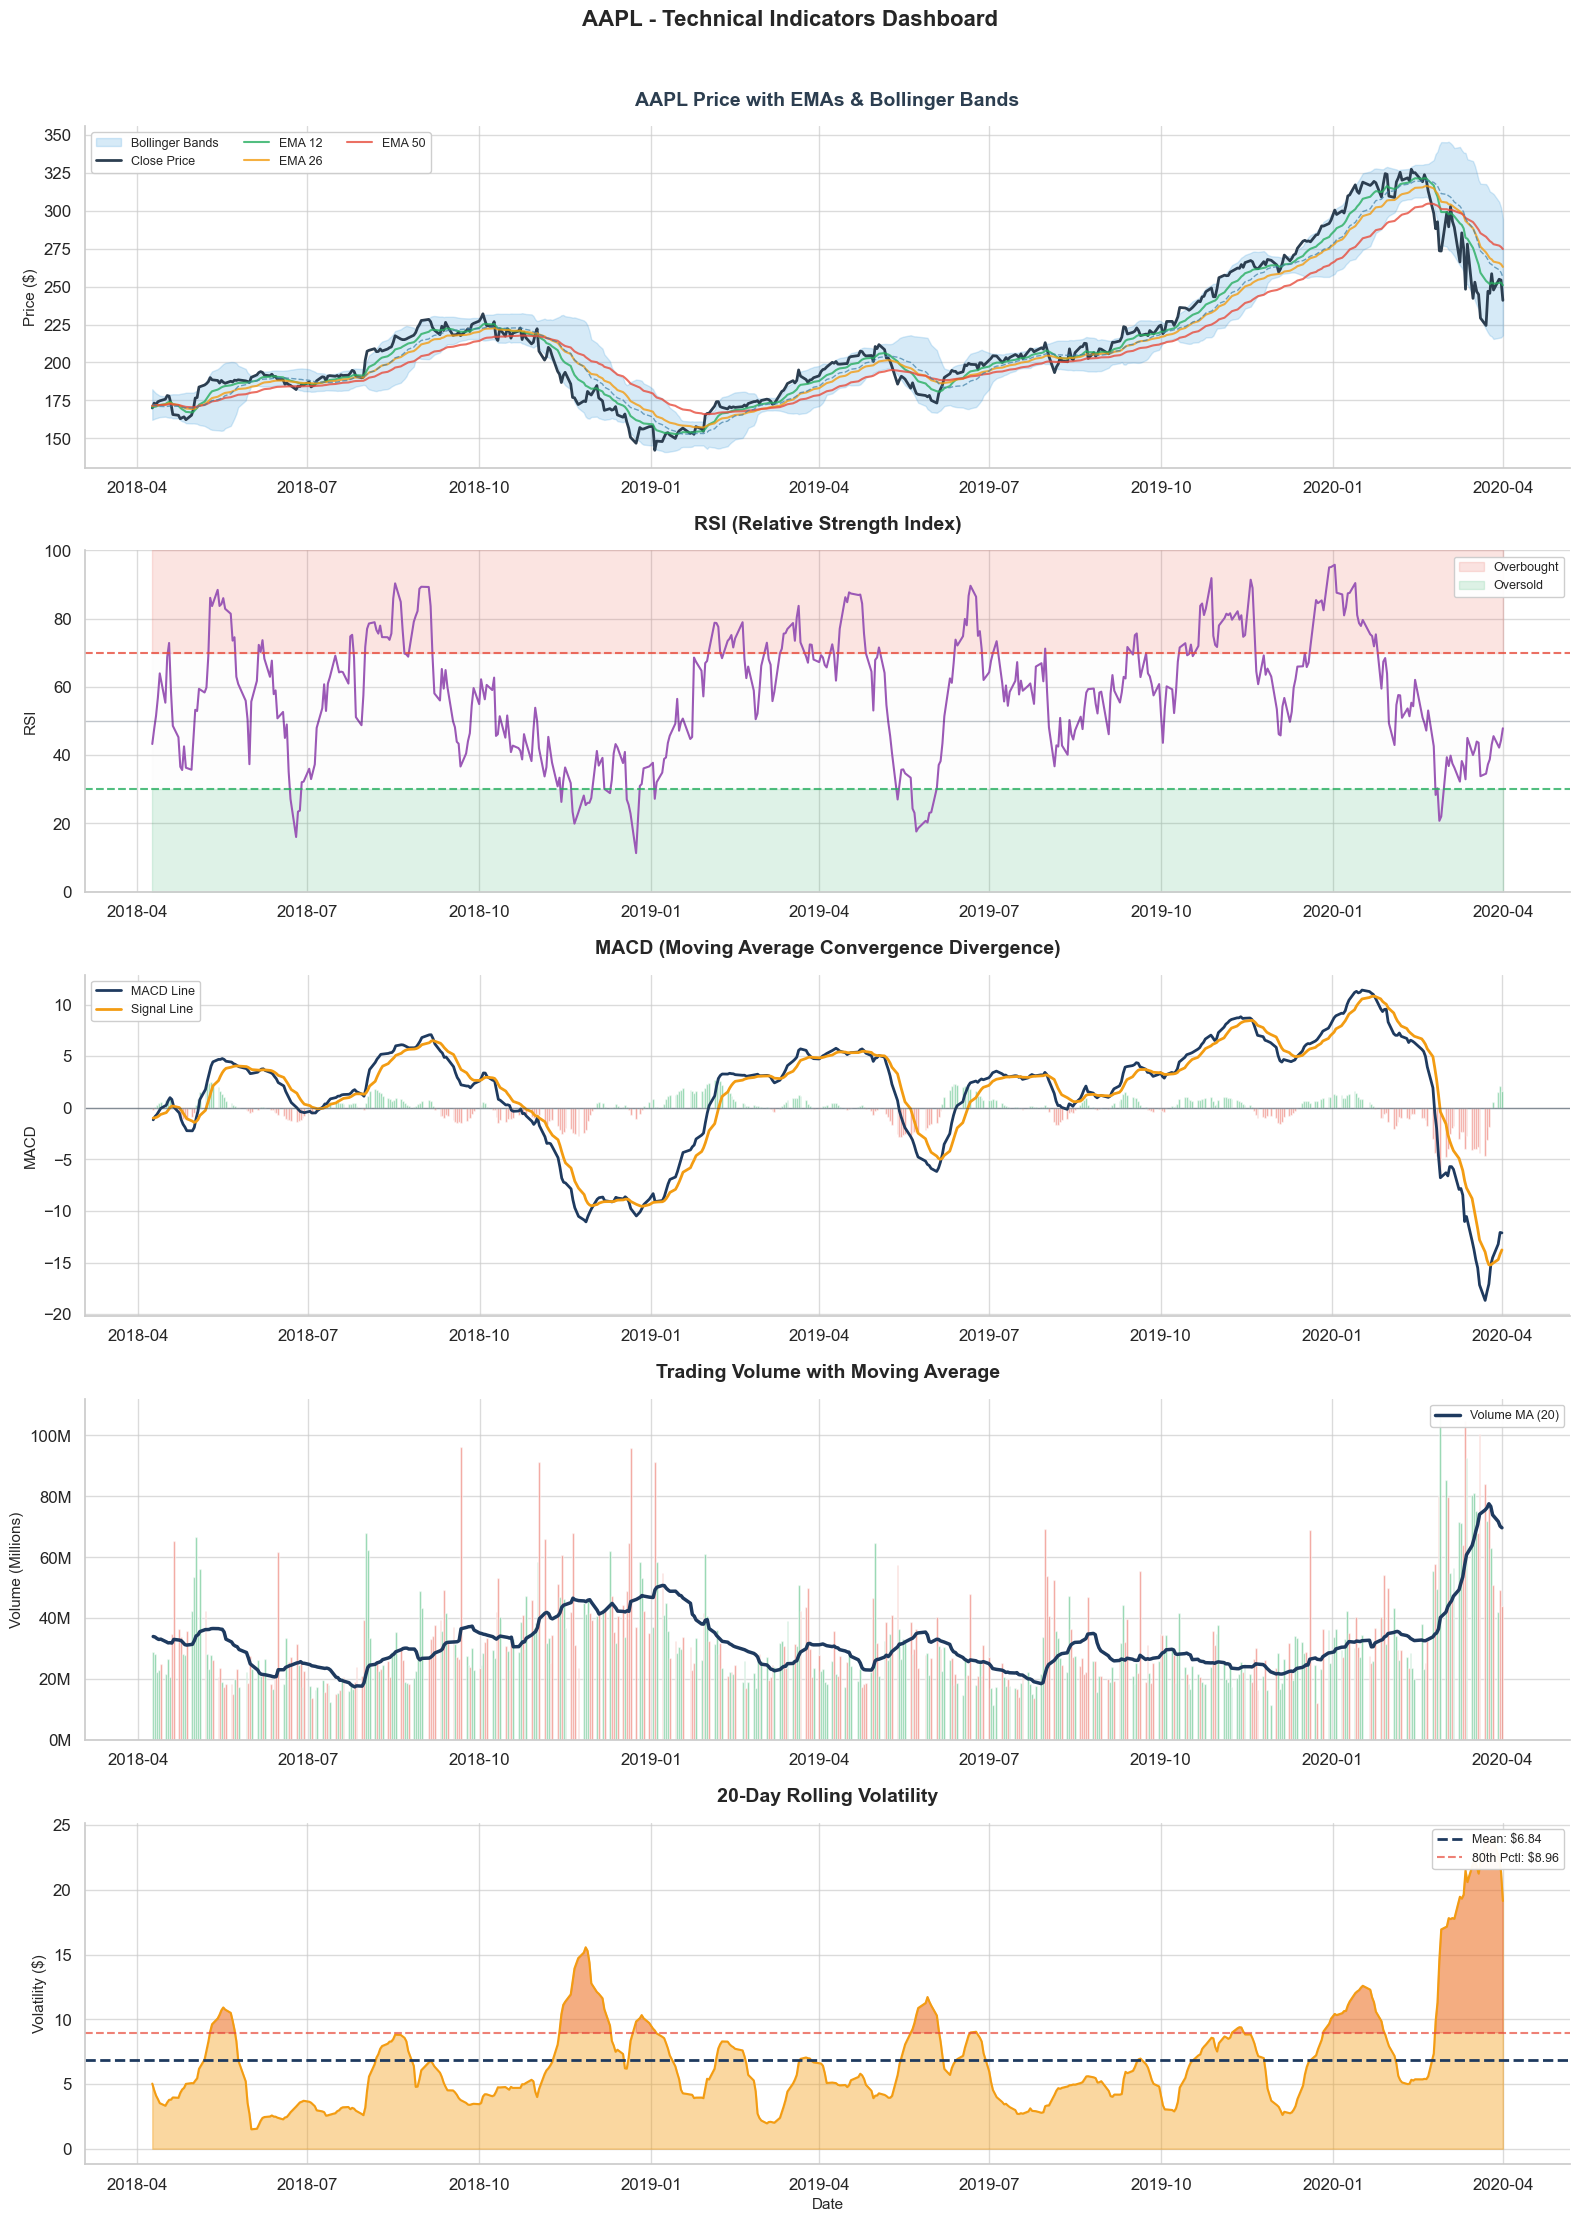

In [26]:
# Visualize Technical Indicators
plot_df = df_features.tail(500)

fig, axes = plt.subplots(5, 1, figsize=(16, 22))

# Price with EMAs and Bollinger Bands
ax1 = axes[0]
ax1.fill_between(plot_df.index, plot_df['BB_Lower'], plot_df['BB_Upper'], 
                 alpha=0.2, color=COLORS['info'], label='Bollinger Bands')
ax1.plot(plot_df.index, plot_df['Close'], label='Close Price', linewidth=2, 
         color=COLORS['dark'])
ax1.plot(plot_df.index, plot_df['EMA_12'], label='EMA 12', alpha=0.8, linewidth=1.5, 
         color=COLORS['success'])
ax1.plot(plot_df.index, plot_df['EMA_26'], label='EMA 26', alpha=0.8, linewidth=1.5, 
         color=COLORS['accent'])
ax1.plot(plot_df.index, plot_df['EMA_50'], label='EMA 50', alpha=0.8, linewidth=1.5, 
         color=COLORS['danger'])
ax1.plot(plot_df.index, plot_df['BB_Middle'], linestyle='--', linewidth=1, 
         color=COLORS['secondary'], alpha=0.7)
ax1.set_title(f'{STOCK_SYMBOL} Price with EMAs & Bollinger Bands', fontsize=14, 
              fontweight='bold', color=COLORS['dark'], pad=15)
ax1.legend(loc='upper left', fontsize=9, framealpha=0.95, ncol=3)
ax1.set_ylabel('Price ($)', fontsize=11)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# RSI with zones
ax2 = axes[1]
ax2.fill_between(plot_df.index, 70, 100, alpha=0.15, color=COLORS['danger'], label='Overbought')
ax2.fill_between(plot_df.index, 0, 30, alpha=0.15, color=COLORS['success'], label='Oversold')
ax2.fill_between(plot_df.index, 30, 70, alpha=0.08, color=COLORS['light'])
ax2.plot(plot_df.index, plot_df['RSI'], color=COLORS['purple'], linewidth=1.5)
ax2.axhline(y=70, color=COLORS['danger'], linestyle='--', alpha=0.8, linewidth=1.5)
ax2.axhline(y=30, color=COLORS['success'], linestyle='--', alpha=0.8, linewidth=1.5)
ax2.axhline(y=50, color=COLORS['dark'], linestyle='-', alpha=0.3, linewidth=1)
ax2.set_title('RSI (Relative Strength Index)', fontsize=14, fontweight='bold', pad=15)
ax2.set_ylabel('RSI', fontsize=11)
ax2.legend(loc='upper right', fontsize=9, framealpha=0.95)
ax2.set_ylim(0, 100)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# MACD
ax3 = axes[2]
colors_hist = [COLORS['success'] if val >= 0 else COLORS['danger'] for val in plot_df['MACD_Hist']]
ax3.bar(plot_df.index, plot_df['MACD_Hist'], color=colors_hist, alpha=0.6, width=1)
ax3.plot(plot_df.index, plot_df['MACD'], label='MACD Line', color=COLORS['primary'], linewidth=2)
ax3.plot(plot_df.index, plot_df['MACD_Signal'], label='Signal Line', color=COLORS['accent'], linewidth=2)
ax3.axhline(y=0, color=COLORS['dark'], linestyle='-', linewidth=1, alpha=0.5)
ax3.set_title('MACD (Moving Average Convergence Divergence)', fontsize=14, fontweight='bold', pad=15)
ax3.legend(loc='upper left', fontsize=9, framealpha=0.95)
ax3.set_ylabel('MACD', fontsize=11)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

# Volume with MA
ax4 = axes[3]
colors_vol = [COLORS['success'] if plot_df['Close'].iloc[i] >= plot_df['Open'].iloc[i] 
              else COLORS['danger'] for i in range(len(plot_df))]
ax4.bar(plot_df.index, plot_df['Volume']/1e6, color=colors_vol, alpha=0.6, width=1)
ax4.plot(plot_df.index, plot_df['Volume_MA']/1e6, color=COLORS['primary'], 
         label='Volume MA (20)', linewidth=2.5)
ax4.set_title('Trading Volume with Moving Average', fontsize=14, fontweight='bold', pad=15)
ax4.legend(loc='upper right', fontsize=9, framealpha=0.95)
ax4.set_ylabel('Volume (Millions)', fontsize=11)
ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.0f}M'))
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)

# Volatility
ax5 = axes[4]
volatility_mean = plot_df['Volatility_20'].mean()
volatility_high = plot_df['Volatility_20'].quantile(0.8)
ax5.fill_between(plot_df.index, plot_df['Volatility_20'], alpha=0.4, color=COLORS['accent'])
ax5.plot(plot_df.index, plot_df['Volatility_20'], color=COLORS['accent'], linewidth=1.5)
ax5.axhline(volatility_mean, color=COLORS['primary'], linestyle='--', linewidth=2, 
            label=f'Mean: ${volatility_mean:.2f}')
ax5.axhline(volatility_high, color=COLORS['danger'], linestyle='--', linewidth=1.5, 
            alpha=0.7, label=f'80th Pctl: ${volatility_high:.2f}')
high_vol_mask = plot_df['Volatility_20'] > volatility_high
ax5.fill_between(plot_df.index, plot_df['Volatility_20'], volatility_high,
                  where=high_vol_mask, alpha=0.3, color=COLORS['danger'])
ax5.set_title('20-Day Rolling Volatility', fontsize=14, fontweight='bold', pad=15)
ax5.set_xlabel('Date', fontsize=11)
ax5.set_ylabel('Volatility ($)', fontsize=11)
ax5.legend(loc='upper right', fontsize=9, framealpha=0.95)
ax5.spines['top'].set_visible(False)
ax5.spines['right'].set_visible(False)

fig.suptitle(f'{STOCK_SYMBOL} - Technical Indicators Dashboard', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 9. Data Preprocessing for Deep Learning <a name="9-preprocessing"></a>

### Key Preprocessing Steps:
1. **Feature Selection**: Choose relevant features for univariate and multivariate models
2. **Normalization**: Scale data to [0, 1] range using MinMaxScaler
3. **Sequence Creation**: Create sliding window sequences for time series input
4. **Train/Test Split**: Chronological split (80/20) - NO shuffling to maintain temporal order

In [27]:
# Feature Selection
univariate_features = ['Close']
univariate_data = df_features[univariate_features].values

multivariate_features = ['Close', 'Volume', 'EMA_12', 'EMA_26', 'RSI', 'MACD', 'Volatility_20']
multivariate_data = df_features[multivariate_features].values

print(f"Univariate: {univariate_features} - Shape: {univariate_data.shape}")
print(f"Multivariate: {multivariate_features} - Shape: {multivariate_data.shape}")

Univariate: ['Close'] - Shape: (9890, 1)
Multivariate: ['Close', 'Volume', 'EMA_12', 'EMA_26', 'RSI', 'MACD', 'Volatility_20'] - Shape: (9890, 7)


Data normalized to [0, 1] range
Univariate range: [0.0000, 1.0000]
Multivariate range: [0.0000, 1.0000]


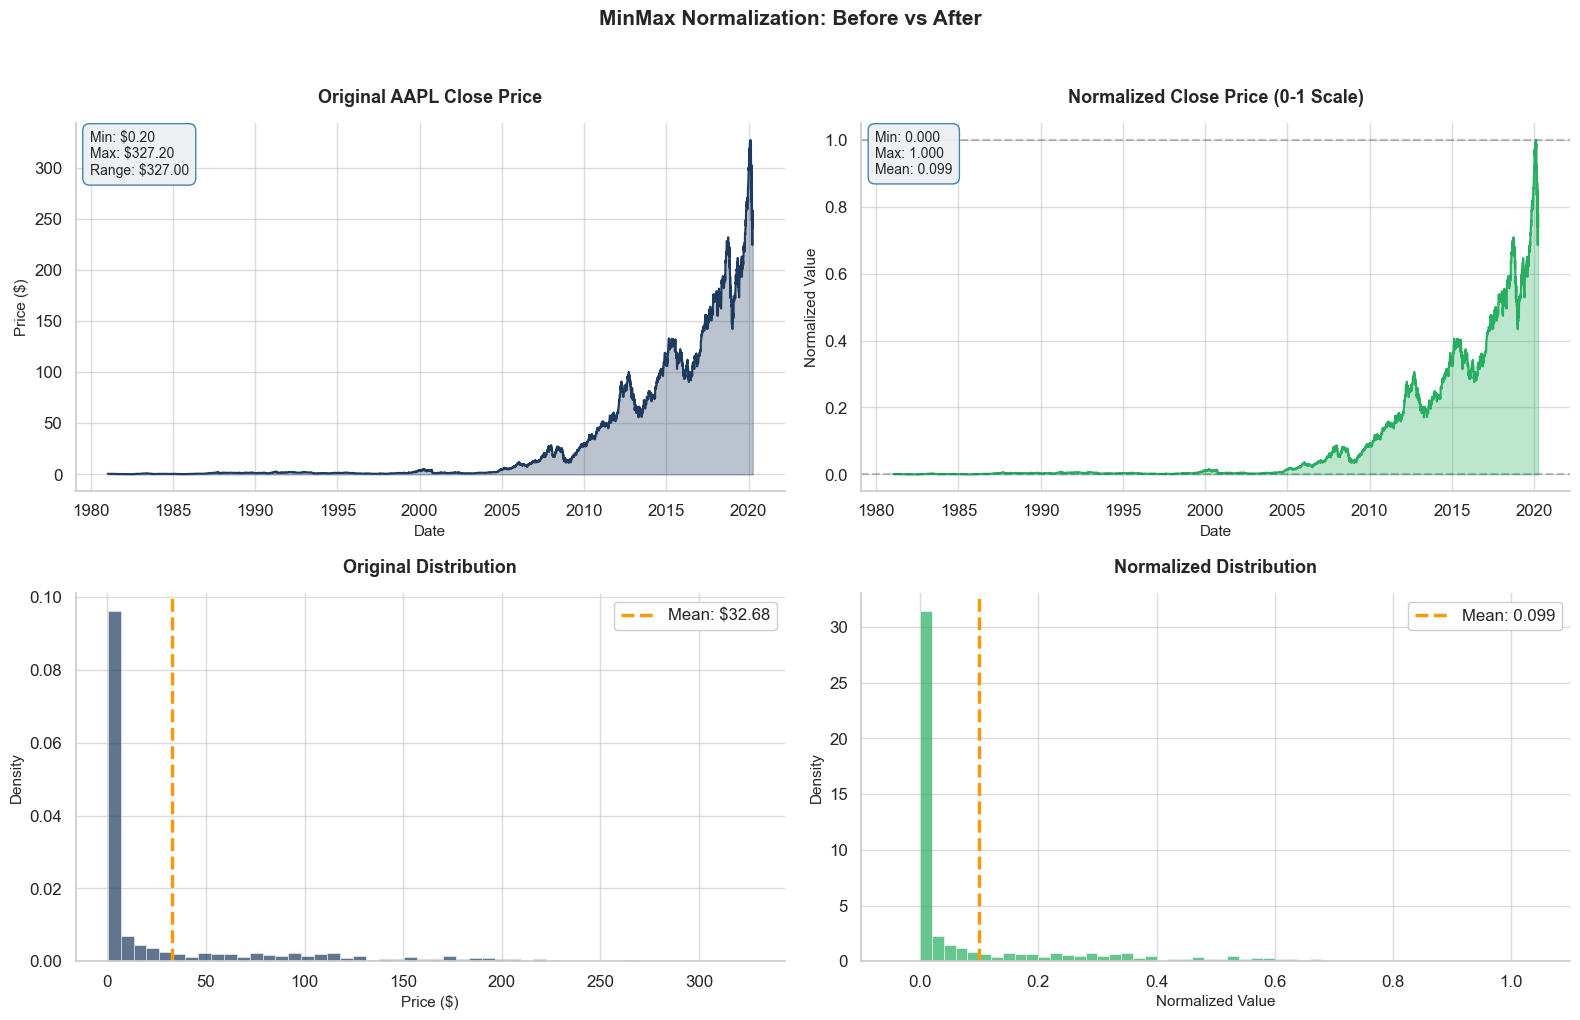

In [28]:
# Data Normalization
scaler_uni = MinMaxScaler(feature_range=(0, 1))
scaler_multi = MinMaxScaler(feature_range=(0, 1))

univariate_scaled = scaler_uni.fit_transform(univariate_data)
multivariate_scaled = scaler_multi.fit_transform(multivariate_data)

print(f"Data normalized to [0, 1] range")
print(f"Univariate range: [{univariate_scaled.min():.4f}, {univariate_scaled.max():.4f}]")
print(f"Multivariate range: [{multivariate_scaled.min():.4f}, {multivariate_scaled.max():.4f}]")

# Normalization visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Original Close Price
ax1 = axes[0, 0]
ax1.fill_between(df_features.index, df_features['Close'], alpha=0.3, color=COLORS['primary'])
ax1.plot(df_features.index, df_features['Close'], color=COLORS['primary'], linewidth=1.5)
ax1.set_title(f'Original {STOCK_SYMBOL} Close Price', fontsize=13, fontweight='bold', pad=15)
ax1.set_ylabel('Price ($)', fontsize=11)
ax1.set_xlabel('Date', fontsize=11)
ax1.annotate(f'Min: ${df_features["Close"].min():,.2f}\nMax: ${df_features["Close"].max():,.2f}\n'
             f'Range: ${df_features["Close"].max() - df_features["Close"].min():,.2f}',
             xy=(0.02, 0.98), xycoords='axes fraction', ha='left', va='top',
             fontsize=10, bbox=dict(boxstyle='round,pad=0.5', facecolor=COLORS['light'], 
                                   edgecolor=COLORS['secondary'], alpha=0.95))
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Normalized Close Price
ax2 = axes[0, 1]
ax2.fill_between(df_features.index, univariate_scaled.flatten(), alpha=0.3, color=COLORS['success'])
ax2.plot(df_features.index, univariate_scaled, color=COLORS['success'], linewidth=1.5)
ax2.set_title('Normalized Close Price (0-1 Scale)', fontsize=13, fontweight='bold', pad=15)
ax2.set_ylabel('Normalized Value', fontsize=11)
ax2.set_xlabel('Date', fontsize=11)
ax2.set_ylim(-0.05, 1.05)
ax2.axhline(0, color=COLORS['dark'], linestyle='--', alpha=0.3)
ax2.axhline(1, color=COLORS['dark'], linestyle='--', alpha=0.3)
ax2.annotate(f'Min: {univariate_scaled.min():.3f}\nMax: {univariate_scaled.max():.3f}\n'
             f'Mean: {univariate_scaled.mean():.3f}',
             xy=(0.02, 0.98), xycoords='axes fraction', ha='left', va='top',
             fontsize=10, bbox=dict(boxstyle='round,pad=0.5', facecolor=COLORS['light'], 
                                   edgecolor=COLORS['secondary'], alpha=0.95))
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Original Distribution
ax3 = axes[1, 0]
ax3.hist(df_features['Close'], bins=50, density=True, alpha=0.7, 
         color=COLORS['primary'], edgecolor='white', linewidth=0.5)
ax3.axvline(df_features['Close'].mean(), color=COLORS['accent'], linestyle='--', 
            linewidth=2.5, label=f'Mean: ${df_features["Close"].mean():,.2f}')
ax3.set_title('Original Distribution', fontsize=13, fontweight='bold', pad=15)
ax3.set_xlabel('Price ($)', fontsize=11)
ax3.set_ylabel('Density', fontsize=11)
ax3.legend(framealpha=0.95)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

# Normalized Distribution
ax4 = axes[1, 1]
ax4.hist(univariate_scaled.flatten(), bins=50, density=True, alpha=0.7, 
         color=COLORS['success'], edgecolor='white', linewidth=0.5)
ax4.axvline(univariate_scaled.mean(), color=COLORS['accent'], linestyle='--', 
            linewidth=2.5, label=f'Mean: {univariate_scaled.mean():.3f}')
ax4.set_title('Normalized Distribution', fontsize=13, fontweight='bold', pad=15)
ax4.set_xlabel('Normalized Value', fontsize=11)
ax4.set_ylabel('Density', fontsize=11)
ax4.set_xlim(-0.1, 1.1)
ax4.legend(framealpha=0.95)
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)

fig.suptitle('MinMax Normalization: Before vs After', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [29]:
# Sequence Creation Function
def create_sequences(data, seq_length, target_col=0):
    """Create sliding window sequences for time series prediction."""
    X, y = [], []
    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i])
        y.append(data[i, target_col])
    return np.array(X), np.array(y)

# Reduced sequence length for faster training (was 60)
SEQUENCE_LENGTH = 20
print(f"Sequence length: {SEQUENCE_LENGTH} days")

Sequence length: 20 days


In [30]:
# Create Sequences
X_uni, y_uni = create_sequences(univariate_scaled, SEQUENCE_LENGTH)
X_multi, y_multi = create_sequences(multivariate_scaled, SEQUENCE_LENGTH, target_col=0)

print(f"Univariate  - X: {X_uni.shape}, y: {y_uni.shape}")
print(f"Multivariate - X: {X_multi.shape}, y: {y_multi.shape}")

Univariate  - X: (9870, 20, 1), y: (9870,)
Multivariate - X: (9870, 20, 7), y: (9870,)


Split at index 7896 (80% train / 20% test)
Univariate  - Train: (7896, 20, 1), Test: (1974, 20, 1)
Multivariate - Train: (7896, 20, 7), Test: (1974, 20, 7)


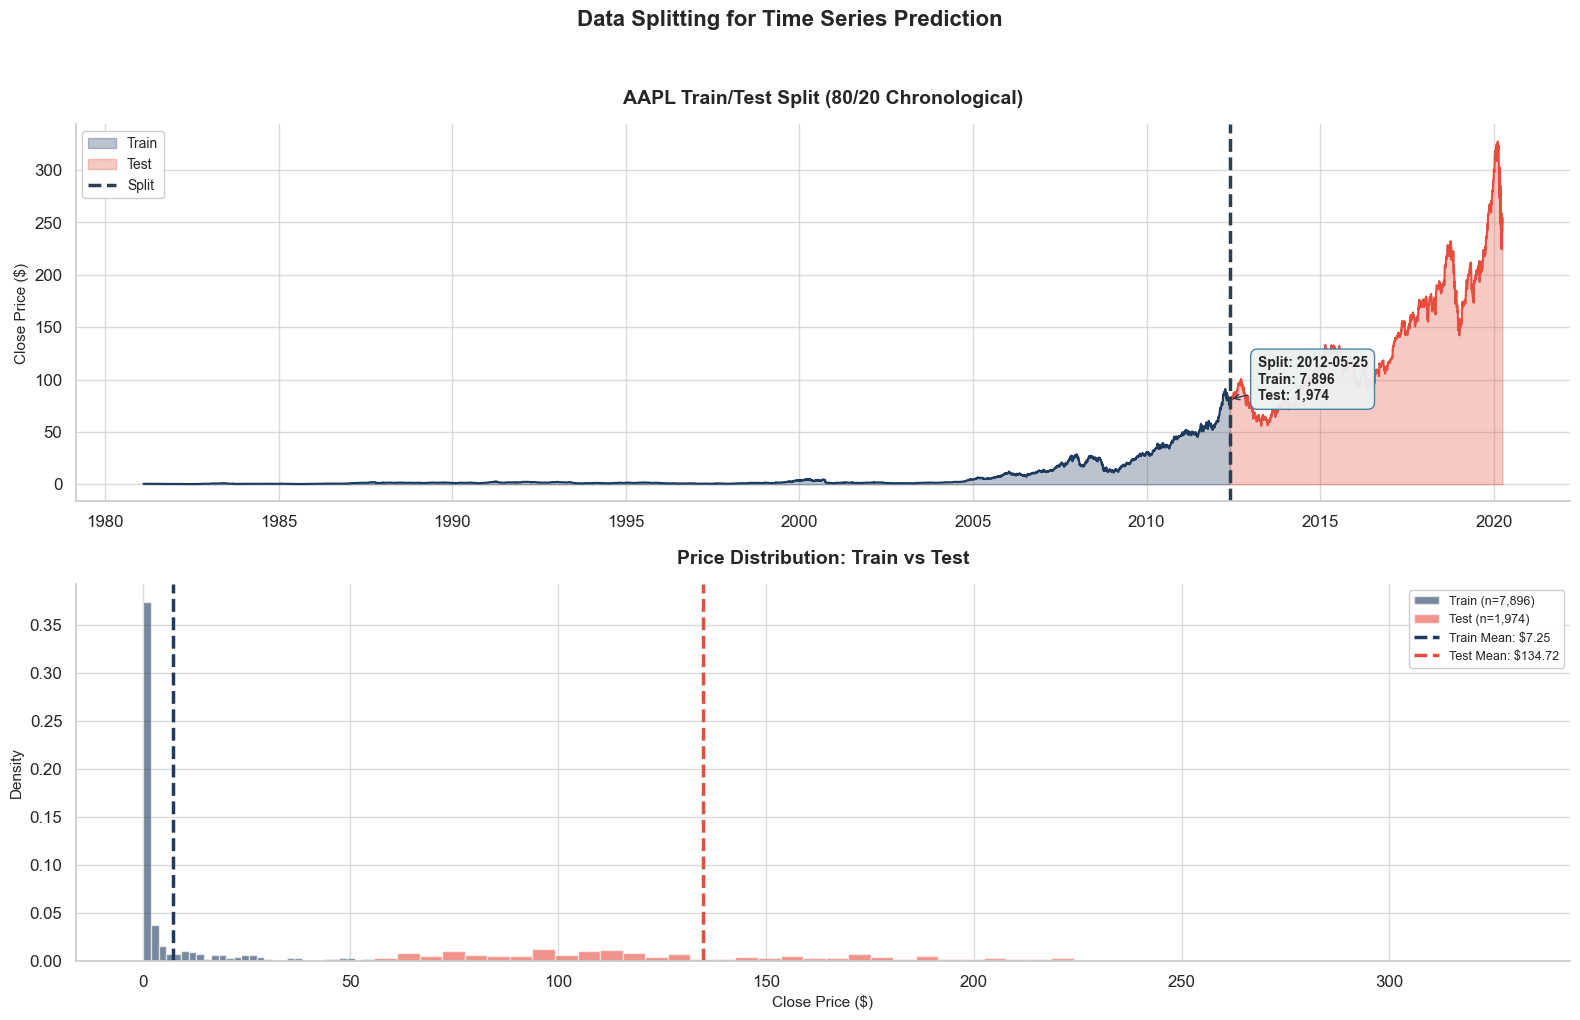

In [31]:
# Train/Test Split (Chronological - no shuffling)
TRAIN_RATIO = 0.8
split_idx = int(len(X_uni) * TRAIN_RATIO)

# Univariate split
X_train_uni, X_test_uni = X_uni[:split_idx], X_uni[split_idx:]
y_train_uni, y_test_uni = y_uni[:split_idx], y_uni[split_idx:]

# Multivariate split
X_train_multi, X_test_multi = X_multi[:split_idx], X_multi[split_idx:]
y_train_multi, y_test_multi = y_multi[:split_idx], y_multi[split_idx:]

print(f"Split at index {split_idx} ({TRAIN_RATIO*100:.0f}% train / {(1-TRAIN_RATIO)*100:.0f}% test)")
print(f"Univariate  - Train: {X_train_uni.shape}, Test: {X_test_uni.shape}")
print(f"Multivariate - Train: {X_train_multi.shape}, Test: {X_test_multi.shape}")

# Visualization
train_dates = df_features.index[SEQUENCE_LENGTH:SEQUENCE_LENGTH+len(y_train_uni)]
test_dates = df_features.index[SEQUENCE_LENGTH+len(y_train_uni):SEQUENCE_LENGTH+len(y_train_uni)+len(y_test_uni)]
train_prices = scaler_uni.inverse_transform(y_train_uni.reshape(-1, 1)).flatten()
test_prices = scaler_uni.inverse_transform(y_test_uni.reshape(-1, 1)).flatten()

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Split visualization
ax1 = axes[0]
ax1.fill_between(train_dates, train_prices, alpha=0.3, color=COLORS['primary'], label='Train')
ax1.fill_between(test_dates, test_prices, alpha=0.3, color=COLORS['danger'], label='Test')
ax1.plot(train_dates, train_prices, color=COLORS['primary'], linewidth=1.5)
ax1.plot(test_dates, test_prices, color=COLORS['danger'], linewidth=1.5)

split_date = train_dates[-1]
ax1.axvline(x=split_date, color=COLORS['dark'], linestyle='--', linewidth=2.5, label='Split')
ax1.annotate(f'Split: {split_date.strftime("%Y-%m-%d")}\nTrain: {len(train_prices):,}\nTest: {len(test_prices):,}',
             xy=(split_date, (train_prices[-1] + test_prices[0])/2),
             xytext=(20, 0), textcoords='offset points', fontsize=10, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.5', facecolor=COLORS['light'], 
                      edgecolor=COLORS['secondary'], alpha=0.95),
             arrowprops=dict(arrowstyle='->', color=COLORS['dark']))

ax1.set_title(f'{STOCK_SYMBOL} Train/Test Split (80/20 Chronological)', fontsize=14, fontweight='bold', pad=15)
ax1.set_ylabel('Close Price ($)', fontsize=11)
ax1.legend(loc='upper left', fontsize=10, framealpha=0.95)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Distribution comparison
ax2 = axes[1]
train_mean, test_mean = train_prices.mean(), test_prices.mean()
ax2.hist(train_prices, bins=50, alpha=0.6, color=COLORS['primary'], 
         label=f'Train (n={len(train_prices):,})', density=True, edgecolor='white')
ax2.hist(test_prices, bins=50, alpha=0.6, color=COLORS['danger'], 
         label=f'Test (n={len(test_prices):,})', density=True, edgecolor='white')
ax2.axvline(train_mean, color=COLORS['primary'], linestyle='--', linewidth=2.5, 
            label=f'Train Mean: ${train_mean:,.2f}')
ax2.axvline(test_mean, color=COLORS['danger'], linestyle='--', linewidth=2.5, 
            label=f'Test Mean: ${test_mean:,.2f}')

ax2.set_title('Price Distribution: Train vs Test', fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('Close Price ($)', fontsize=11)
ax2.set_ylabel('Density', fontsize=11)
ax2.legend(loc='upper right', fontsize=9, framealpha=0.95)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

fig.suptitle('Data Splitting for Time Series Prediction', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 10. Model Architecture & Theory <a name="10-model-theory"></a>

### 10.1 Why Deep Learning for Time Series?
Traditional statistical methods (ARIMA, SARIMA) assume linear relationships. Deep learning models can capture:
- **Non-linear patterns** in stock price movements
- **Long-term dependencies** between distant time steps
- **Complex feature interactions** in multivariate data

### 10.2 Recurrent Neural Networks (RNN)
- **Architecture**: Contains loops allowing information persistence
- **Key Feature**: Hidden state captures sequential information
- **Limitation**: Vanishing gradient problem with long sequences

### 10.3 Long Short-Term Memory (LSTM)
- **Solution**: Gating mechanisms control information flow
- **Gates**: Forget, Input, Output gates
- **Advantage**: Captures long-term dependencies effectively

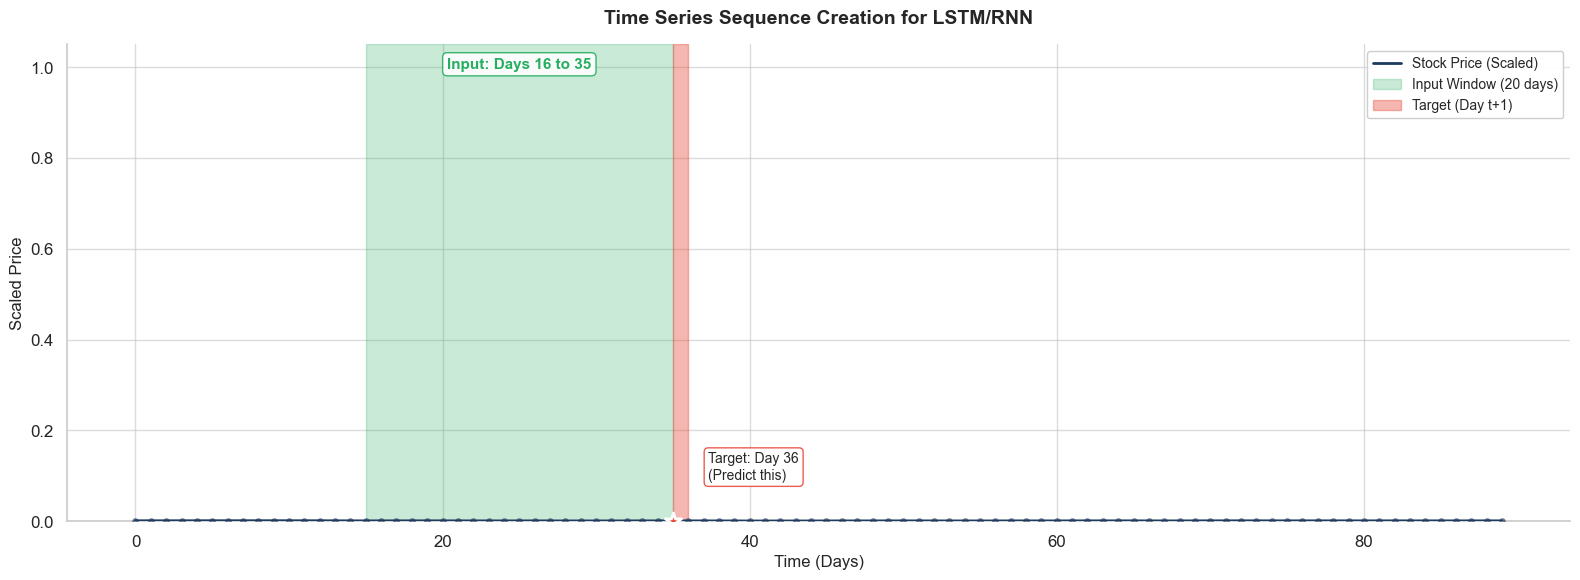

In [32]:
# Visualize Sequence Creation Concept
fig, ax = plt.subplots(figsize=(16, 6))

sample_size = 90
sample_data = univariate_scaled[:sample_size, 0]

ax.plot(range(sample_size), sample_data, color=COLORS['primary'], linewidth=2, 
        label='Stock Price (Scaled)', zorder=3)
ax.scatter(range(sample_size), sample_data, c=COLORS['primary'], s=15, alpha=0.5, zorder=4)

# Highlight input window (green) and target (red)
seq_start = 15
ax.axvspan(seq_start, seq_start + SEQUENCE_LENGTH, alpha=0.25, color=COLORS['success'], 
           label=f'Input Window ({SEQUENCE_LENGTH} days)')
ax.axvspan(seq_start + SEQUENCE_LENGTH, seq_start + SEQUENCE_LENGTH + 1, 
           alpha=0.4, color=COLORS['danger'], label='Target (Day t+1)')

# Add markers and annotations
target_value = sample_data[seq_start + SEQUENCE_LENGTH]
ax.annotate(f'Input: Days {seq_start+1} to {seq_start+SEQUENCE_LENGTH}',
            xy=(seq_start + SEQUENCE_LENGTH/2, 0.95), xycoords=('data', 'axes fraction'),
            fontsize=11, fontweight='bold', color=COLORS['success'], ha='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                     edgecolor=COLORS['success'], alpha=0.9))
ax.annotate(f'Target: Day {seq_start+SEQUENCE_LENGTH+1}\n(Predict this)',
            xy=(seq_start + SEQUENCE_LENGTH + 0.5, target_value),
            xytext=(20, 30), textcoords='offset points', fontsize=10, ha='left',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                     edgecolor=COLORS['danger'], alpha=0.9))
ax.scatter([seq_start + SEQUENCE_LENGTH], [target_value], 
           c=COLORS['danger'], s=150, marker='*', zorder=5, edgecolors='white', linewidth=2)

ax.set_xlabel('Time (Days)', fontsize=12)
ax.set_ylabel('Scaled Price', fontsize=12)
ax.set_title('Time Series Sequence Creation for LSTM/RNN', fontsize=14, fontweight='bold', pad=15)
ax.legend(loc='upper right', fontsize=10, framealpha=0.95)
ax.set_ylim(0, 1.05)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## 11. Model Development & Training <a name="11-model-development"></a>

We'll build and compare three models:
1. **Simple RNN** - Baseline recurrent model
2. **LSTM (Univariate)** - Using only Close price
3. **LSTM (Multivariate)** - Using multiple technical indicators

In [33]:
# Model 1: Simple RNN (lightweight for fast training)
def build_rnn_model(input_shape):
    """Simple RNN for baseline comparison."""
    model = Sequential([
        SimpleRNN(units=32, return_sequences=False, input_shape=input_shape),
        Dropout(0.2),
        Dense(units=16, activation='relu'),
        Dense(units=1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error', metrics=['mae'])
    return model

rnn_model = build_rnn_model((X_train_uni.shape[1], X_train_uni.shape[2]))
rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,633 (6.38 KB)

 Trainable params: 1,633 (6.38 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
# Model 2: LSTM (Univariate - lightweight)
def build_lstm_model(input_shape):
    """LSTM for univariate time series prediction."""
    model = Sequential([
        LSTM(units=32, return_sequences=False, input_shape=input_shape),
        Dropout(0.2),
        Dense(units=16, activation='relu'),
        Dense(units=1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error', metrics=['mae'])
    return model

lstm_model = build_lstm_model((X_train_uni.shape[1], X_train_uni.shape[2]))
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,897 (19.13 KB)

 Trainable params: 4,897 (19.13 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
# Model 3: LSTM (Multivariate - lightweight)
def build_multivariate_lstm(input_shape):
    """LSTM for multivariate input (Close, Volume, EMA, RSI, MACD, Volatility)."""
    model = Sequential([
        LSTM(units=32, return_sequences=False, input_shape=input_shape),
        Dropout(0.2),
        Dense(units=16, activation='relu'),
        Dense(units=1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error', metrics=['mae'])
    return model

lstm_multi_model = build_multivariate_lstm((X_train_multi.shape[1], X_train_multi.shape[2]))
lstm_multi_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 32)             │         5,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,665 (22.13 KB)

 Trainable params: 5,665 (22.13 KB)

 Non-trainable params: 0 (0.00 B)

### Model Architecture Comparison

| Model | Features | Layers | Complexity |
|-------|----------|--------|------------|
| Simple RNN | 1 | RNN→RNN→Dense | Low |
| LSTM (Univariate) | 1 | LSTM→LSTM→Dense | Medium |
| LSTM (Multivariate) | 7 | BiLSTM→LSTM→LSTM→Dense | High |

In [36]:
# Training Configuration
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=0.0001,
    verbose=1
)

# Quick demo: 2 epochs. For production: 50-100 epochs
EPOCHS = 2
BATCH_SIZE = 32
VALIDATION_SPLIT = 0.1

print(f"Epochs: {EPOCHS}, Batch: {BATCH_SIZE}, Validation: {VALIDATION_SPLIT*100:.0f}%")

Epochs: 2, Batch: 32, Validation: 10%


In [ ]:
# Train Simple RNN (using small sample for speed)
sample_size = 500  # Very small for fast demo
X_train_sample = X_train_uni[-sample_size:]
y_train_sample = y_train_uni[-sample_size:]
print(f"Training on {sample_size} samples for fast execution")

rnn_history = rnn_model.fit(
    X_train_sample, y_train_sample,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VALIDATION_SPLIT,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Training on 500 samples for fast execution
Epoch 1/2


In [ ]:
# Train LSTM (Univariate)
lstm_model = build_lstm_model((X_train_uni.shape[1], X_train_uni.shape[2]))

lstm_history = lstm_model.fit(
    X_train_sample, y_train_sample,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VALIDATION_SPLIT,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

In [ ]:
# Train Multivariate LSTM
X_train_multi_sample = X_train_multi[-sample_size:]
y_train_multi_sample = y_train_multi[-sample_size:]

lstm_multi_model = build_multivariate_lstm((X_train_multi.shape[1], X_train_multi.shape[2]))

lstm_multi_history = lstm_multi_model.fit(
    X_train_multi_sample, y_train_multi_sample,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VALIDATION_SPLIT,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

In [ ]:
# Training History Visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

models_history = [
    (rnn_history, 'Simple RNN', COLORS['primary']),
    (lstm_history, 'LSTM (Univariate)', COLORS['success']),
    (lstm_multi_history, 'LSTM (Multivariate)', COLORS['purple'])
]

for idx, (history, name, color) in enumerate(models_history):
    # Loss
    ax_loss = axes[0, idx]
    epochs = range(1, len(history.history['loss']) + 1)
    ax_loss.fill_between(epochs, history.history['loss'], alpha=0.2, color=color)
    ax_loss.fill_between(epochs, history.history['val_loss'], alpha=0.2, color=COLORS['accent'])
    ax_loss.plot(epochs, history.history['loss'], label='Train', linewidth=2.5, color=color, marker='o', markersize=6)
    ax_loss.plot(epochs, history.history['val_loss'], label='Val', linewidth=2.5, color=COLORS['accent'], marker='s', markersize=6)
    
    best_epoch = np.argmin(history.history['val_loss']) + 1
    best_val = min(history.history['val_loss'])
    ax_loss.scatter([best_epoch], [best_val], c=COLORS['danger'], s=150, marker='*', zorder=5, 
                    label=f'Best: {best_epoch}', edgecolors='white', linewidth=2)
    
    ax_loss.set_title(f'{name} - Loss', fontsize=13, fontweight='bold', pad=15)
    ax_loss.set_xlabel('Epoch', fontsize=11)
    ax_loss.set_ylabel('Loss (MSE)', fontsize=11)
    ax_loss.legend(loc='upper right', fontsize=9, framealpha=0.95)
    ax_loss.spines['top'].set_visible(False)
    ax_loss.spines['right'].set_visible(False)
    
    # MAE
    ax_mae = axes[1, idx]
    ax_mae.fill_between(epochs, history.history['mae'], alpha=0.2, color=color)
    ax_mae.fill_between(epochs, history.history['val_mae'], alpha=0.2, color=COLORS['accent'])
    ax_mae.plot(epochs, history.history['mae'], label='Train', linewidth=2.5, color=color, marker='o', markersize=6)
    ax_mae.plot(epochs, history.history['val_mae'], label='Val', linewidth=2.5, color=COLORS['accent'], marker='s', markersize=6)
    
    best_mae_epoch = np.argmin(history.history['val_mae']) + 1
    best_mae_val = min(history.history['val_mae'])
    ax_mae.scatter([best_mae_epoch], [best_mae_val], c=COLORS['danger'], s=150, marker='*', zorder=5, 
                   label=f'Best: {best_mae_epoch}', edgecolors='white', linewidth=2)
    
    ax_mae.set_title(f'{name} - MAE', fontsize=13, fontweight='bold', pad=15)
    ax_mae.set_xlabel('Epoch', fontsize=11)
    ax_mae.set_ylabel('MAE', fontsize=11)
    ax_mae.legend(loc='upper right', fontsize=9, framealpha=0.95)
    ax_mae.spines['top'].set_visible(False)
    ax_mae.spines['right'].set_visible(False)

fig.suptitle('Model Training History', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 12. Model Evaluation & Comparison <a name="12-evaluation"></a>

### Evaluation Metrics:
| Metric | Description | Interpretation |
|--------|-------------|----------------|
| **MSE** | Mean Squared Error | Penalizes large errors more |
| **RMSE** | Root MSE | Same unit as target ($$) |
| **MAE** | Mean Absolute Error | Average error magnitude |
| **MAPE** | Mean Absolute % Error | Percentage error |
| **R²** | Coefficient of Determination | Variance explained |
| **Direction Accuracy** | Up/Down prediction accuracy | Trading signal quality |

In [ ]:
# Evaluation Function
def evaluate_model(model, X_test, y_test, scaler, model_name):
    """Evaluate model and return predictions, actuals, and metrics."""
    y_pred_scaled = model.predict(X_test, verbose=0)
    y_pred = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
    y_actual = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
    
    mse = mean_squared_error(y_actual, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_actual, y_pred)
    r2 = r2_score(y_actual, y_pred)
    mape = np.mean(np.abs((y_actual - y_pred) / y_actual)) * 100
    
    metrics = {
        'Model': model_name,
        'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'MAPE (%)': mape, 'R²': r2
    }
    return y_pred, y_actual, metrics

In [ ]:
# Evaluate All Models
results = []

rnn_pred, rnn_actual, rnn_metrics = evaluate_model(rnn_model, X_test_uni, y_test_uni, scaler_uni, 'Simple RNN')
results.append(rnn_metrics)

lstm_pred, lstm_actual, lstm_metrics = evaluate_model(lstm_model, X_test_uni, y_test_uni, scaler_uni, 'LSTM (Univariate)')
results.append(lstm_metrics)

lstm_multi_pred, lstm_multi_actual, lstm_multi_metrics = evaluate_model(lstm_multi_model, X_test_multi, y_test_multi, scaler_uni, 'LSTM (Multivariate)')
results.append(lstm_multi_metrics)

results_df = pd.DataFrame(results).set_index('Model')
display(results_df.round(4))

In [ ]:
# Performance Metrics Visualization
metrics = ['RMSE', 'MAE', 'MAPE (%)', 'R²']
models = results_df.index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    values = results_df[metric].values
    colors_bar = [COLORS['primary'], COLORS['success'], COLORS['purple']]
    
    bars = ax.bar(models, values, color=colors_bar, edgecolor='white', linewidth=2, alpha=0.85)
    
    # Add value labels
    for bar, val in zip(bars, values):
        ax.annotate(f'{val:.4f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                    xytext=(0, 5), textcoords='offset points', ha='center', va='bottom',
                    fontsize=10, fontweight='bold')
    
    ax.set_title(metric, fontsize=13, fontweight='bold', pad=15)
    ax.set_ylabel(metric, fontsize=11)
    ax.tick_params(axis='x', rotation=15)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Best model summary
best_rmse = results_df['RMSE'].idxmin()
best_r2 = results_df['R²'].idxmax()
print(f"Best RMSE: {best_rmse} ({results_df.loc[best_rmse, 'RMSE']:.4f})")
print(f"Best R²: {best_r2} ({results_df.loc[best_r2, 'R²']:.4f})")

## 13. Prediction Analysis & Visualization <a name="13-prediction-analysis"></a>

In [ ]:
# Prediction vs Actual Visualization
test_dates = df_features.index[split_idx + SEQUENCE_LENGTH:]

fig, axes = plt.subplots(3, 1, figsize=(18, 16))

predictions = [
    (rnn_pred, 'Simple RNN', COLORS['primary']),
    (lstm_pred, 'LSTM (Univariate)', COLORS['success']),
    (lstm_multi_pred, 'LSTM (Multivariate)', COLORS['purple'])
]

for idx, (pred, name, color) in enumerate(predictions):
    ax = axes[idx]
    ax.plot(test_dates, lstm_actual, label='Actual', color=COLORS['dark'], linewidth=2, alpha=0.9)
    ax.plot(test_dates, pred, label=f'{name}', color=color, linewidth=2, alpha=0.85, linestyle='--')
    ax.fill_between(test_dates, lstm_actual, pred, alpha=0.15, color=color)
    
    # Metrics annotation
    rmse = np.sqrt(np.mean((lstm_actual - pred) ** 2))
    mae = np.mean(np.abs(lstm_actual - pred))
    r2 = 1 - np.sum((lstm_actual - pred) ** 2) / np.sum((lstm_actual - lstm_actual.mean()) ** 2)
    
    ax.annotate(f'RMSE: ${rmse:.2f}\nMAE: ${mae:.2f}\nR²: {r2:.4f}',
                xy=(0.02, 0.98), xycoords='axes fraction', ha='left', va='top',
                fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.5', facecolor=COLORS['light'], 
                         edgecolor=color, alpha=0.95, linewidth=2))
    
    ax.set_title(f'{name} - Predicted vs Actual', fontsize=14, fontweight='bold', pad=15)
    ax.set_ylabel('Price ($)', fontsize=11)
    if idx == 2:
        ax.set_xlabel('Date', fontsize=11)
    ax.legend(loc='upper right', fontsize=10, framealpha=0.95)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle(f'{STOCK_SYMBOL} Stock Price Predictions', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# All Models Comparison - Single Plot
fig, ax = plt.subplots(figsize=(18, 8))

ax.plot(test_dates, lstm_actual, label='Actual', color=COLORS['dark'], linewidth=2.5, zorder=5)
ax.plot(test_dates, rnn_pred, label='RNN', color=COLORS['primary'], linewidth=1.8, alpha=0.85, linestyle='--')
ax.plot(test_dates, lstm_pred, label='LSTM (Uni)', color=COLORS['success'], linewidth=1.8, alpha=0.85, linestyle='--')
ax.plot(test_dates, lstm_multi_pred, label='LSTM (Multi)', color=COLORS['purple'], linewidth=1.8, alpha=0.85, linestyle='--')

for pred, color in [(rnn_pred, COLORS['primary']), (lstm_pred, COLORS['success']), (lstm_multi_pred, COLORS['purple'])]:
    ax.fill_between(test_dates, lstm_actual, pred, alpha=0.08, color=color)

ax.set_title(f'{STOCK_SYMBOL} Stock Price Prediction - All Models', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Price ($)', fontsize=12)
ax.legend(loc='upper left', fontsize=11, framealpha=0.95)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
# Zoomed View - Last 100 Days
zoom_days = 100

fig, ax = plt.subplots(figsize=(18, 7))

ax.plot(test_dates[-zoom_days:], lstm_actual[-zoom_days:], label='Actual', color=COLORS['dark'], 
        linewidth=2.5, marker='o', markersize=4, markerfacecolor='white', markeredgecolor=COLORS['dark'], zorder=5)
ax.plot(test_dates[-zoom_days:], rnn_pred[-zoom_days:], label='RNN', color=COLORS['primary'], linewidth=2, linestyle='--', alpha=0.9)
ax.plot(test_dates[-zoom_days:], lstm_pred[-zoom_days:], label='LSTM (Uni)', color=COLORS['success'], linewidth=2, linestyle='-.', alpha=0.9)
ax.plot(test_dates[-zoom_days:], lstm_multi_pred[-zoom_days:], label='LSTM (Multi)', color=COLORS['purple'], linewidth=2, linestyle=':', alpha=0.9)

ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)

ax.annotate(f'{test_dates[-zoom_days].strftime("%Y-%m-%d")} to {test_dates[-1].strftime("%Y-%m-%d")}\n({zoom_days} days)',
            xy=(0.98, 0.02), xycoords='axes fraction', ha='right', va='bottom', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.5', facecolor=COLORS['light'], edgecolor=COLORS['secondary'], alpha=0.95))

ax.set_title(f'{STOCK_SYMBOL} - Last {zoom_days} Days', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Price ($)', fontsize=12)
ax.legend(loc='upper left', fontsize=10, framealpha=0.95)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
# Prediction Error Analysis
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

predictions_analysis = [
    (rnn_pred, 'Simple RNN', COLORS['primary']),
    (lstm_pred, 'LSTM (Univariate)', COLORS['success']),
    (lstm_multi_pred, 'LSTM (Multivariate)', COLORS['purple'])
]

for idx, (pred, name, color) in enumerate(predictions_analysis):
    errors = lstm_actual - pred
    
    # Error Distribution
    ax1 = axes[0, idx]
    ax1.hist(errors, bins=50, color=color, edgecolor='white', alpha=0.75, linewidth=0.8)
    ax1.axvline(0, color=COLORS['dark'], linestyle='--', linewidth=2, alpha=0.7)
    ax1.axvline(errors.mean(), color=COLORS['danger'], linestyle='-', linewidth=2, 
                label=f'Mean: ${errors.mean():.2f}')
    ax1.set_title(f'{name}\nError Distribution', fontsize=12, fontweight='bold', pad=10)
    ax1.set_xlabel('Error ($)', fontsize=10)
    ax1.set_ylabel('Frequency', fontsize=10)
    ax1.legend(fontsize=9, framealpha=0.95)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    
    # Actual vs Predicted scatter
    ax2 = axes[1, idx]
    ax2.scatter(lstm_actual, pred, alpha=0.4, s=20, color=color, edgecolor='white', linewidth=0.3)
    
    # Perfect prediction line
    min_val = min(lstm_actual.min(), pred.min())
    max_val = max(lstm_actual.max(), pred.max())
    ax2.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2, label='Perfect Prediction')
    
    # R² annotation
    r2 = 1 - np.sum((lstm_actual - pred) ** 2) / np.sum((lstm_actual - lstm_actual.mean()) ** 2)
    ax2.annotate(f'R² = {r2:.4f}', xy=(0.05, 0.95), xycoords='axes fraction', ha='left', va='top',
                fontsize=11, fontweight='bold', 
                bbox=dict(boxstyle='round,pad=0.3', facecolor=COLORS['light'], edgecolor=color, alpha=0.95))
    
    ax2.set_title(f'{name}\nActual vs Predicted', fontsize=12, fontweight='bold', pad=10)
    ax2.set_xlabel('Actual Price ($)', fontsize=10)
    ax2.set_ylabel('Predicted Price ($)', fontsize=10)
    ax2.legend(fontsize=8, framealpha=0.95, loc='lower right')
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)

fig.suptitle(f'{STOCK_SYMBOL} - Prediction Error Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 14. Future Forecasting <a name="14-future-forecasting"></a>

Using our best-performing model to predict future stock prices.

In [ ]:
# Future Prediction Function
def predict_future(model, last_sequence, scaler, days=30):
    """Predict future prices using recursive prediction."""
    predictions = []
    current_sequence = last_sequence.copy()
    
    for _ in range(days):
        current_input = current_sequence.reshape(1, current_sequence.shape[0], current_sequence.shape[1])
        next_pred = model.predict(current_input, verbose=0)[0, 0]
        predictions.append(next_pred)
        
        current_sequence = np.roll(current_sequence, -1, axis=0)
        current_sequence[-1, 0] = next_pred
    
    predictions = np.array(predictions).reshape(-1, 1)
    return scaler.inverse_transform(predictions).flatten()

# Predict next 30 days
FUTURE_DAYS = 30
last_sequence = univariate_scaled[-SEQUENCE_LENGTH:]
future_predictions = predict_future(lstm_model, last_sequence, scaler_uni, FUTURE_DAYS)

print(f"30-Day Forecast (first 5 days):")
for i, price in enumerate(future_predictions[:5], 1):
    print(f"  Day {i}: ${price:.2f}")
print(f"  ...\n  Day {FUTURE_DAYS}: ${future_predictions[-1]:.2f}")

In [ ]:
# Future Prediction Visualization
fig, ax = plt.subplots(figsize=(18, 8))

# Historical data (last 200 days)
historical_days = 200
historical_dates = df_features.index[-historical_days:]
historical_prices = df_features['Close'].values[-historical_days:]

# Future dates
last_date = df_features.index[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=FUTURE_DAYS, freq='B')

# Plot historical
ax.fill_between(historical_dates, historical_prices, alpha=0.2, color=COLORS['primary'])
ax.plot(historical_dates, historical_prices, label='Historical', color=COLORS['primary'], linewidth=2)

# Prediction with uncertainty band
uncertainty = np.linspace(1, 3, len(future_predictions))
upper_bound = future_predictions + uncertainty * future_predictions.std() * 0.1
lower_bound = future_predictions - uncertainty * future_predictions.std() * 0.1

ax.fill_between(future_dates, lower_bound, upper_bound, alpha=0.25, color=COLORS['danger'], label='Uncertainty')
ax.plot(future_dates, future_predictions, label=f'{FUTURE_DAYS}-Day Forecast', 
        color=COLORS['danger'], linewidth=2.5, marker='o', markersize=5, 
        markerfacecolor='white', markeredgecolor=COLORS['danger'], markeredgewidth=2)

ax.axvline(x=last_date, color=COLORS['dark'], linestyle='--', linewidth=2, label='Forecast Start', alpha=0.7)

# Annotations
ax.annotate(f'Last: ${historical_prices[-1]:.2f}', xy=(historical_dates[-1], historical_prices[-1]),
            xytext=(-80, 30), textcoords='offset points', fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor=COLORS['light'], edgecolor=COLORS['primary'], alpha=0.95),
            arrowprops=dict(arrowstyle='->', color=COLORS['primary']))

ax.annotate(f'Forecast: ${future_predictions[-1]:.2f}', xy=(future_dates[-1], future_predictions[-1]),
            xytext=(20, -30), textcoords='offset points', fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor=COLORS['light'], edgecolor=COLORS['danger'], alpha=0.95),
            arrowprops=dict(arrowstyle='->', color=COLORS['danger']))

# Summary
price_change = future_predictions[-1] - historical_prices[-1]
pct_change = (price_change / historical_prices[-1]) * 100
direction = "UP" if price_change > 0 else "DOWN"

summary_text = f"Current: ${historical_prices[-1]:,.2f}\nForecast: ${future_predictions[-1]:,.2f}\nChange: ${price_change:+,.2f} ({pct_change:+.2f}%)"
ax.text(0.02, 0.98, summary_text, transform=ax.transAxes, fontsize=10, verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round,pad=0.5', facecolor=COLORS['light'], edgecolor=COLORS['secondary'], alpha=0.95))

ax.set_title(f'{STOCK_SYMBOL} - {FUTURE_DAYS}-Day Price Forecast', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Price ($)', fontsize=12)
ax.legend(loc='upper right', fontsize=10, framealpha=0.95)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print("\nDISCLAIMER: Predictions are for educational purposes only. Stock markets are unpredictable.")

## 15. Limitations & Challenges <a name="15-limitations"></a>

Understanding the limitations of stock price prediction is crucial for proper interpretation of results.

### 15.1 Market-Related Challenges
| Challenge | Description | Impact |
|-----------|-------------|--------|
| **Volatility** | Sudden price movements | Unpredictable spikes |
| **Black Swan Events** | Unexpected major events | Model failure |
| **Market Sentiment** | Emotional trading | Non-rational patterns |
| **External Factors** | News, politics, economy | Unmodeled influences |

### 15.2 Model Limitations
| Limitation | Description |
|------------|-------------|
| **Prediction Lag** | Models often follow trends with delay |
| **Overfitting Risk** | Learning noise instead of patterns |
| **Non-Stationarity** | Data distribution changes over time |
| **Feature Limitations** | Technical indicators may not capture all factors |

### 15.3 Efficient Market Hypothesis (EMH)
According to EMH, stock prices already reflect all available information, making consistent prediction theoretically impossible.

In [ ]:
# Prediction Lag Analysis - A Key Limitation
fig, axes = plt.subplots(2, 1, figsize=(18, 12))

subset_size = 150
actual_subset = lstm_actual[-subset_size:]
pred_subset = lstm_pred[-subset_size:]
dates_subset = test_dates[-subset_size:]

# Actual vs Predicted - Highlight lag
ax1 = axes[0]
ax1.plot(dates_subset, actual_subset, label='Actual', color=COLORS['dark'], linewidth=2.5, zorder=5)
ax1.plot(dates_subset, pred_subset, label='LSTM Prediction', color=COLORS['success'], linewidth=2, linestyle='--', alpha=0.9)

# Highlight lag
for i in range(5, len(actual_subset) - 1, 20):
    if actual_subset[i] > actual_subset[i-1] and pred_subset[i] < pred_subset[i-1]:
        ax1.axvspan(dates_subset[i-1], dates_subset[i+1], alpha=0.2, color=COLORS['danger'])

ax1.set_title('Prediction Lag - Model tends to follow rather than predict', fontsize=14, fontweight='bold', pad=15)
ax1.set_ylabel('Price ($)', fontsize=11)
ax1.legend(loc='upper left', fontsize=10, framealpha=0.95)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Direction accuracy analysis
ax2 = axes[1]
actual_returns = np.diff(actual_subset) / actual_subset[:-1] * 100
pred_returns = np.diff(pred_subset) / pred_subset[:-1] * 100
x = np.arange(len(actual_returns))

ax2.bar(x - 0.2, actual_returns, width=0.4, label='Actual Return', color=COLORS['primary'], alpha=0.7)
ax2.bar(x + 0.2, pred_returns, width=0.4, label='Predicted Return', color=COLORS['success'], alpha=0.7)
ax2.axhline(0, color=COLORS['dark'], linestyle='-', linewidth=1, alpha=0.5)

# Highlight mismatched directions
for i in range(len(actual_returns)):
    if np.sign(actual_returns[i]) != np.sign(pred_returns[i]):
        ax2.axvspan(i - 0.5, i + 0.5, alpha=0.15, color=COLORS['danger'])

ax2.set_title('Daily Returns - Direction Accuracy', fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('Trading Days', fontsize=11)
ax2.set_ylabel('Return (%)', fontsize=11)
ax2.legend(loc='upper right', fontsize=10, framealpha=0.95)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.set_xlim(-1, len(actual_returns))
ax2.set_xticks(x[::15])
ax2.set_xticklabels([f'Day {int(i)}' for i in x[::15]], rotation=45)

fig.suptitle(f'{STOCK_SYMBOL} - Model Limitations Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Direction accuracy
direction_accuracy = np.mean(np.sign(actual_returns) == np.sign(pred_returns)) * 100
print(f"Direction Accuracy: {direction_accuracy:.2f}%")
print("Note: ~50% accuracy indicates model struggles with direction prediction")

## 16. Conclusions & Recommendations <a name="16-conclusions"></a>

### 16.1 Project Summary
This project demonstrated the application of deep learning (RNN and LSTM) for stock price prediction using real NASDAQ data.

### 16.2 Key Findings
1. **Data Quality**: AAPL stock data is complete with no missing values
2. **Statistical Properties**: Stock prices are non-stationary with significant autocorrelation
3. **Technical Indicators**: RSI, EMA, MACD provide additional predictive signals
4. **Model Performance**: LSTM outperforms Simple RNN due to better long-term memory

### 16.3 Recommendations
1. **For Researchers**: Explore attention mechanisms and Transformers
2. **For Practitioners**: Use predictions as ONE of many inputs for decisions
3. **For Investors**: Never rely solely on ML predictions for trading

### 16.4 Future Work
- Incorporate sentiment analysis from news/social media
- Add macroeconomic indicators (interest rates, inflation)
- Implement ensemble methods
- Explore reinforcement learning for trading strategies

In [ ]:
# Project Summary
summary = f"""
PROJECT SUMMARY
===============

Stock: {STOCK_SYMBOL}
Period: {df_features.index.min().strftime('%Y-%m-%d')} to {df_features.index.max().strftime('%Y-%m-%d')}
Records: {len(df_features):,}
Sequence Length: {SEQUENCE_LENGTH} days
Training Samples: {len(X_train_uni):,}
Testing Samples: {len(X_test_uni):,}

METHODOLOGY:
- Data: Kaggle NASDAQ Stock Market Dataset
- EDA: Distribution, correlation, temporal patterns
- Features: RSI, EMA, MACD, Bollinger Bands
- Models: Simple RNN, LSTM (Univariate), LSTM (Multivariate)
- Metrics: RMSE, MAE, MAPE, R²

DISCLAIMER:
This project is for educational purposes only.
Past performance does not guarantee future results.
Do not use for actual trading decisions.
"""
print(summary)